### Replicando para BR

In [1]:
# pip install yfinance pandas requests lxml openpyxl

import re
import time
import math
import requests
import pandas as pd
import yfinance as yf

HEADERS = {"User-Agent": "Mozilla/5.0"}

# ========= 1) Pegar universo (IBrX 100 ou Ibovespa) =========
def fetch_index_tickers(index: str = "IBRX") -> list[str]:
    """
    index:
      - "IBRX" -> IBrX 100 (carteira teórica)
      - "IBOV" -> Ibovespa (carteira teórica)
    Fonte: site antigo BM&FBOVESPA/B3 (bem parseável)
    """
    index = index.upper().strip()
    if index not in {"IBRX", "IBOV"}:
        raise ValueError("index deve ser 'IBRX' (IBrX 100) ou 'IBOV' (Ibovespa)")

    url = f"https://bvmf.bmfbovespa.com.br/indices/ResumoCarteiraTeorica.aspx?Indice={index}&idioma=pt-br"
    html = requests.get(url, headers=HEADERS, timeout=30).text

    # Tenta primeiro via read_html
    tickers = []
    try:
        tables = pd.read_html(html)
        for tb in tables:
            cols = [str(c).lower() for c in tb.columns]
            # geralmente a 1a coluna é "Código"
            if any("código" in c or "codigo" in c for c in cols):
                col = tb.columns[0]
                tickers = (
                    tb[col].astype(str)
                    .str.upper().str.strip()
                    .tolist()
                )
                break
    except ValueError:
        pass

    # Fallback por regex (pega coisas tipo PETR4, BPAC11, KLBN11 etc.)
    if not tickers:
        tickers = re.findall(r"\b[A-Z]{4}\d{1,2}\b", html)

    # Filtra e remove duplicatas mantendo ordem
    seen = set()
    out = []
    for t in tickers:
        t = t.strip().upper()
        if re.match(r"^[A-Z]{4}\d{1,2}$", t) and t not in seen:
            seen.add(t)
            out.append(t)

    return out

def to_yahoo_sa(tickers_b3: list[str]) -> list[str]:
    return [f"{t}.SA" if not t.endswith(".SA") else t for t in tickers_b3]


# ========= 2) Baixar preços (Close ajustado) em lotes =========
def chunked(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def extract_close(df: pd.DataFrame, tickers_sa: list[str]) -> pd.DataFrame:
    """
    Normaliza a saída do yf.download para sempre retornar um DataFrame
    com colunas = tickers e valores = Close.
    """
    if df is None or df.empty:
        return pd.DataFrame()

    # Caso multi-ticker: geralmente vem MultiIndex com nível "Close"
    if isinstance(df.columns, pd.MultiIndex):
        # tenta no formato df["Close"]
        if "Close" in df.columns.get_level_values(0):
            close = df["Close"].copy()
            # garante só os tickers pedidos (às vezes vem coisa extra)
            close = close.loc[:, [c for c in close.columns if c in tickers_sa]]
            return close

        # fallback: procura nível com "Close"
        for level in range(df.columns.nlevels):
            if "Close" in df.columns.get_level_values(level):
                # tenta selecionar onde esse nível == Close
                close_cols = [c for c in df.columns if "Close" in c]
                close = df.loc[:, close_cols].copy()
                return close

    # Caso single-ticker
    if "Close" in df.columns:
        # Descobre ticker único (quando você passa 1 ativo)
        # e cria DF com coluna = ticker
        # Se não souber, usa "SINGLE"
        colname = tickers_sa[0] if tickers_sa else "SINGLE"
        return df[["Close"]].rename(columns={"Close": colname})

    return pd.DataFrame()

def download_closes(tickers_sa: list[str], start: str, end: str,
                    batch_size: int = 25, max_retries: int = 3, delay: int = 3) -> tuple[pd.DataFrame, list[str]]:
    """
    Baixa Close ajustado (auto_adjust=True) para uma lista de tickers .SA em lotes.
    Retorna (close_df, failures)
    """
    all_close = []
    failures = []

    for batch in chunked(tickers_sa, batch_size):
        got = None
        for attempt in range(1, max_retries + 1):
            try:
                df = yf.download(
                    tickers=batch,
                    start=start,
                    end=end,
                    auto_adjust=True,   # usa preços ajustados do Yahoo
                    progress=False,
                    threads=True,
                    timeout=30,
                    group_by="column"
                )
                got = extract_close(df, batch)
                break
            except Exception:
                if attempt == max_retries:
                    got = pd.DataFrame()
                else:
                    time.sleep(delay)

        # Se vier vazio, marca todos do batch como falha
        if got is None or got.empty:
            failures.extend(batch)
        else:
            # identifica tickers que não vieram
            missing = [t for t in batch if t not in got.columns]
            failures.extend(missing)
            # mantém só colunas ok
            got = got.loc[:, [c for c in got.columns if c in batch]]
            all_close.append(got)

    if not all_close:
        return pd.DataFrame(), sorted(set(failures))

    close_df = pd.concat(all_close, axis=1)
    # remove colunas duplicadas (se acontecer)
    close_df = close_df.loc[:, ~close_df.columns.duplicated()]
    close_df = close_df.sort_index()
    return close_df, sorted(set(failures))


def save_prices_csv(close_df: pd.DataFrame, filepath: str):
    close_df.to_csv(filepath, index=True)



In [2]:

# Escolha do universo (tanto faz, você disse): "IBRX" ou "IBOV"
#INDEX = "IBRX"  # recomendo IBrX 100
INDEX = "IBOV"

tickers_b3 = fetch_index_tickers(INDEX)
tickers_sa = to_yahoo_sa(tickers_b3)

print(f"Universo {INDEX}: {len(tickers_sa)} tickers")

# Períodos
start = "1997-01-02"

# 1997–2007 (end exclusivo)
end_2007 = "2008-01-01"
close_9707, fail_9707 = download_closes(tickers_sa, start, end_2007, batch_size=25)
print(f"[INFO] Tickers sem dados no Yahoo: {len(fail_9707)}")
save_prices_csv(close_9707, "precos_1997_2007.csv")
print("Salvo: precos_1997_2007.csv")

# 1997–2025 (end exclusivo)
end_2025 = "2026-01-01"
close_9725, fail_9725 = download_closes(tickers_sa, start, end_2025, batch_size=20)
print(f"[INFO] Tickers sem dados no Yahoo: {len(fail_9725)}")
save_prices_csv(close_9725, "precos_1997_2025.csv")
print("Salvo: precos_1997_2025.csv")

C:\Users\savio\AppData\Local\Temp\ipykernel_1504\1243103092.py:30: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


Universo IBOV: 81 tickers


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CPLE6.SA"}}}

15 Failed downloads:
['BTOW3.SA', 'CIEL3.SA', 'BRDT3.SA', 'BRML3.SA', 'CPLE6.SA', 'CRFB3.SA', 'BRFS3.SA', 'CCRO3.SA']: YFTzMissingError('possibly delisted; no timezone found')
['BPAC11.SA', 'ASAI3.SA', 'CVCB3.SA', 'BBDC4.SA', 'COGN3.SA', 'AZUL4.SA', 'BBSE3.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2008-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 852170400, endDate = 1199152800")')

16 Failed downloads:
['GOLL4.SA', 'ELET3.SA', 'ENBR3.SA', 'GNDI3.SA', 'EMBR3.SA', 'JBSS3.SA', 'ELET6.SA', 'IGTA3.SA', 'HGTX3.SA']: YFTzMissingError('possibly delisted; no timezone found')
['FLRY3.SA', 'EQTL3.SA', 'ENGI11.SA', 'IRBR3.SA', 'HYPE3.SA', 'HAPV3.SA', 'ECOR3.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 1997-01-02 -> 2008-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 85217

[INFO] Tickers sem dados no Yahoo: 0
Salvo: precos_1997_2007.csv



6 Failed downloads:
['CIEL3.SA', 'BTOW3.SA', 'BRML3.SA', 'BRDT3.SA', 'BRFS3.SA', 'CCRO3.SA']: YFTzMissingError('possibly delisted; no timezone found')

7 Failed downloads:
['ENBR3.SA', 'CPLE6.SA', 'GNDI3.SA', 'ELET3.SA', 'CRFB3.SA', 'EMBR3.SA', 'ELET6.SA']: YFTzMissingError('possibly delisted; no timezone found')

8 Failed downloads:
['LCAM3.SA', 'NTCO3.SA', 'MRFG3.SA', 'LAME4.SA', 'GOLL4.SA', 'JBSS3.SA', 'IGTA3.SA', 'HGTX3.SA']: YFTzMissingError('possibly delisted; no timezone found')

2 Failed downloads:
['VVAR3.SA', 'SULA11.SA']: YFTzMissingError('possibly delisted; no timezone found')


[INFO] Tickers sem dados no Yahoo: 0
Salvo: precos_1997_2025.csv


In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import requests
import time
import optuna
import threading

from funcoes import (
    pca_portfolio_hedge,
    pca_portfolio_quantil,
    pca_portfolio_adaptive_pcs,
    stats_from_returns,
    optimize_optuna
)

from analise_estrategia import analyze_strategy 

In [4]:
# Carregar dados
start_date = "2000-01-03"
end_date = "2007-12-31"

data = pd.read_csv("precos_1997_2007.csv", index_col=0)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

returns = data.pct_change()
returns.dropna(inplace=True,axis=0, how='all')
returns.dropna(inplace=True,axis=1, how='any')

# Ibovespa no Yahoo é ^BVSP
data_ibov = yf.download("^BVSP", start=start_date, end=end_date, auto_adjust=True, progress=False)["Close"]
data_ibov.index = pd.to_datetime(data_ibov.index).tz_localize(None)
data_ibov = data_ibov.sort_index()

returns_ibov = data_ibov.pct_change().dropna()
returns_ibov.name = "IBOV"

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns.index     = pd.to_datetime(returns.index).tz_localize(None)
returns_ibov.index = pd.to_datetime(returns_ibov.index).tz_localize(None)
returns     = returns.sort_index()
returns_ibov = returns_ibov.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_12668\3217714990.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()


In [5]:
# pegar os tickers e atualizar os dados até 2025
tickers = data.columns.tolist()
len(tickers)

81

In [6]:
bad_tickers = []

for col in data.columns:
    p = data[col]
    if p.min() <= 0:
        bad_tickers.append(col)
        continue
    if (p.max() / p.min()) > 1e3:  # variação absurda de escala
        bad_tickers.append(col)

data = data.drop(columns=bad_tickers, errors="ignore")
returns = returns.drop(columns=bad_tickers, errors="ignore")

bad_tickers

['BRKM5.SA', 'CMIG4.SA', 'GGBR4.SA', 'LREN3.SA', 'UGPA3.SA']

In [7]:
bad_tickers += ['CPFE3.SA']
tickers = list(set(tickers) - set(bad_tickers))
data = data.drop(columns=set(bad_tickers), errors="ignore")
returns = returns.drop(columns=set(bad_tickers), errors="ignore")

len(tickers)

75

In [8]:
returns.head()

,BBAS3.SA,BBDC3.SA,BRAP4.SA,CSNA3.SA,CYRE3.SA,GOAU4.SA,ITSA4.SA,PETR3.SA,PETR4.SA,SBSP3.SA,USIM5.SA,VALE3.SA,VIVT3.SA,WEGE3.SA
Date,,,,,,,,,,,,,,
2000-01-04,-0.047561,-0.072728,-0.071429,0.014389,0.000000,-0.034482,-0.095477,-0.056123,-0.055319,-0.059288,-0.036458,-0.023810,-0.027083,-0.035093
2000-01-05,0.010243,0.033986,0.076923,0.053698,0.000000,-0.014286,0.083333,0.013514,-0.010090,-0.027828,0.095136,0.000000,0.011135,0.000000
2000-01-06,0.013942,0.015171,0.000000,0.045192,0.000000,0.010870,0.015384,-0.008000,-0.003458,-0.005014,0.090819,0.000000,0.022024,-0.090911
2000-01-07,-0.022500,0.017434,0.000000,-0.006440,0.000000,0.003584,-0.005049,0.008064,0.004566,0.014062,0.039819,0.036586,0.004974,0.000000
2000-01-10,0.054988,0.004897,0.000000,0.012037,0.021739,0.046428,0.035532,0.029333,0.020545,0.063153,0.103568,0.082353,0.061856,0.000000


Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

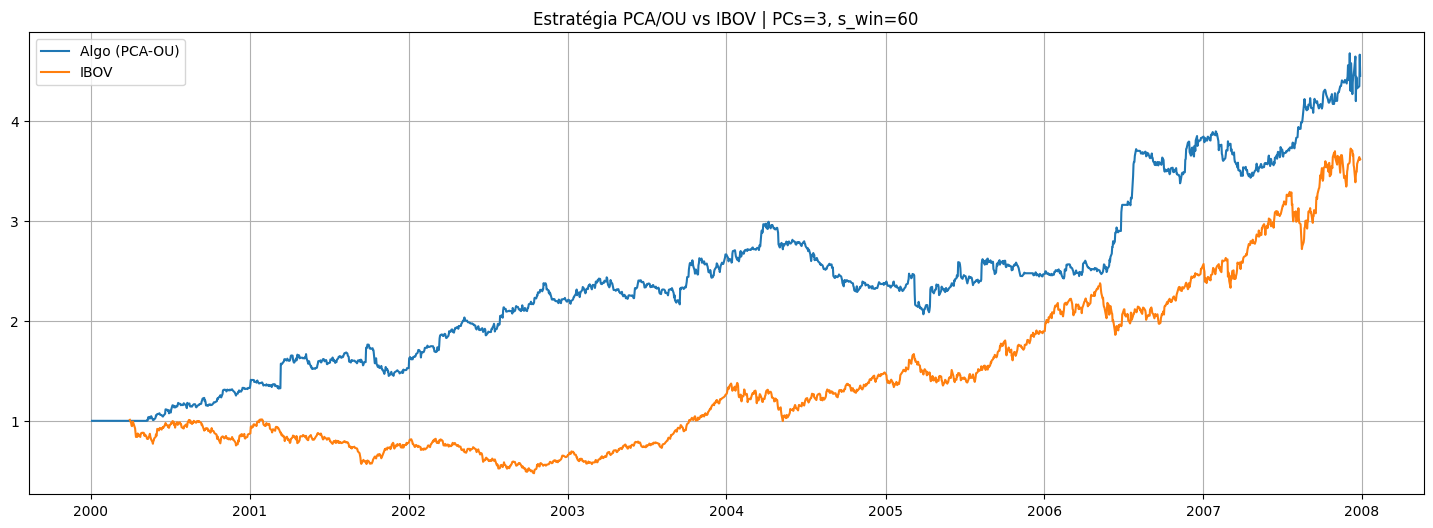

In [8]:
# COM HEDGE (sem drift)

results2 = pca_portfolio_hedge(
    returns=returns,
    returns_bench=returns_ibov,
    benchmark="IBOV",
    num_pc=3,
    s_win=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    #kappa_min=8.4, # padrão
    kappa_min=5.0,
    #kappa_min=10.0,
    plot=True,
    use_drift=False
)

In [11]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.2012 (  20.12%)
  Vol       :     0.1949 (  19.49%)
  Sharpe    :     1.0323 ( 103.23%)
  MaxDD     :    -0.3096 ( -30.96%)



Tempo : 2000-06-20 00:00:00
Tempo : 2000-06-21 00:00:00
Tempo : 2000-06-22 00:00:00
Tempo : 2000-06-23 00:00:00
Tempo : 2000-06-26 00:00:00
Tempo : 2000-06-27 00:00:00
Tempo : 2000-06-28 00:00:00
Tempo : 2000-06-29 00:00:00
Tempo : 2000-06-30 00:00:00
Tempo : 2000-07-03 00:00:00
Tempo : 2000-07-04 00:00:00
Tempo : 2000-07-05 00:00:00
Tempo : 2000-07-06 00:00:00
Tempo : 2000-07-07 00:00:00
Tempo : 2000-07-10 00:00:00
Tempo : 2000-07-11 00:00:00
Tempo : 2000-07-12 00:00:00
Tempo : 2000-07-13 00:00:00
Tempo : 2000-07-14 00:00:00
Tempo : 2000-07-17 00:00:00
Tempo : 2000-07-18 00:00:00
Tempo : 2000-07-19 00:00:00
Tempo : 2000-07-20 00:00:00
Tempo : 2000-07-21 00:00:00
Tempo : 2000-07-24 00:00:00
Tempo : 2000-07-25 00:00:00
Tempo : 2000-07-26 00:00:00
Tempo : 2000-07-27 00:00:00
Tempo : 2000-07-28 00:00:00
Tempo : 2000-07-31 00:00:00
Tempo : 2000-08-01 00:00:00
Tempo : 2000-08-02 00:00:00
Tempo : 2000-08-03 00:00:00
Tempo : 2000-08-04 00:00:00
Tempo : 2000-08-07 00:00:00
Tempo : 2000-08-08 0

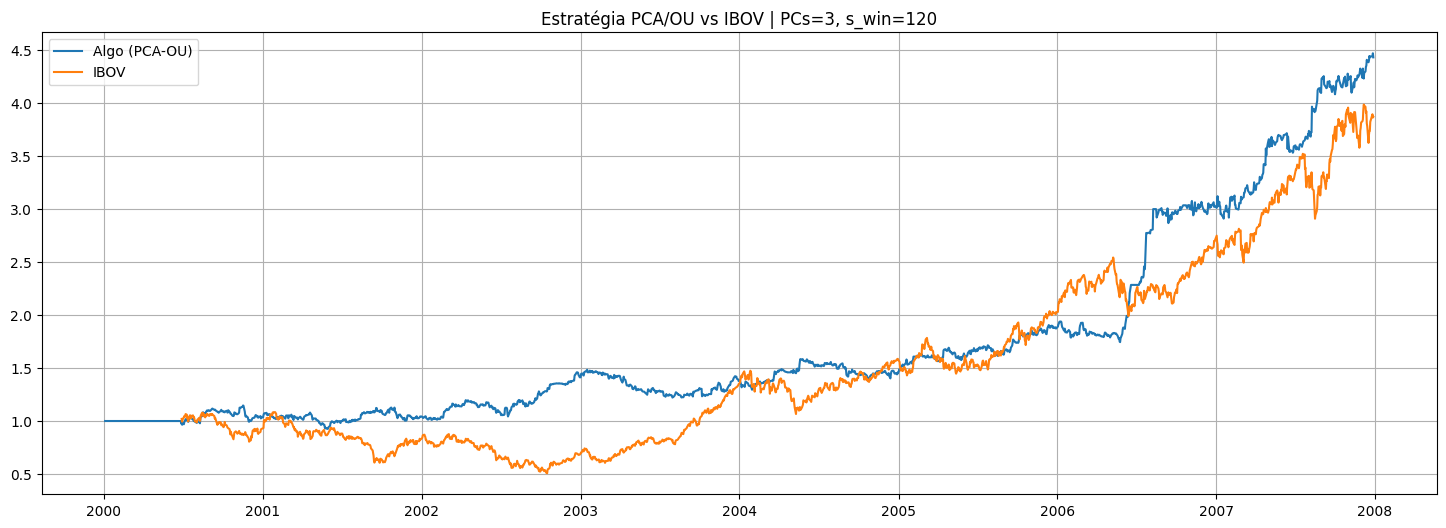

In [9]:
# COM HEDGE (com drift)

results2 = pca_portfolio_hedge(
    returns=returns,
    returns_bench=returns_ibov,
    benchmark="IBOV",
    num_pc=3,
    s_win=120,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    #kappa_min=8.4, # padrão
    kappa_min=5.0,
    #kappa_min=10.0,
    plot=True,
    use_drift=True,
    ma_window=60
)

In [10]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net2 = results2['ret_net']
stats2 = stats_from_returns(ret_net2)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats2.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")



PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.2002 (  20.02%)
  Vol       :     0.1691 (  16.91%)
  Sharpe    :     1.1841 ( 118.41%)
  MaxDD     :    -0.1926 ( -19.26%)



In [11]:
adj_map2 = results2['adj_map']
adj_map2

{'BBAS3.SA': -0.028623771465149918,
 'BBDC3.SA': 0.1257401102379933,
 'BRAP4.SA': 0.3151030888339717,
 'CSNA3.SA': -0.028283056158974022,
 'CYRE3.SA': 0.08927889046109265,
 'GOAU4.SA': 0.18963424857317324,
 'ITSA4.SA': -0.004896348362617925,
 'PETR3.SA': 0.10322162181195381,
 'PETR4.SA': 0.18805830892139644,
 'SBSP3.SA': -0.01284628042637373,
 'USIM5.SA': 0.10000128195274201,
 'VALE3.SA': 0.2787909276728851,
 'VIVT3.SA': -0.2938505003541467,
 'WEGE3.SA': 0.029395305635884623}

Tempo : 2000-06-20 00:00:00
Tempo : 2000-06-21 00:00:00
Tempo : 2000-06-22 00:00:00
Tempo : 2000-06-23 00:00:00
Tempo : 2000-06-26 00:00:00
Tempo : 2000-06-27 00:00:00
Tempo : 2000-06-28 00:00:00
Tempo : 2000-06-29 00:00:00
Tempo : 2000-06-30 00:00:00
Tempo : 2000-07-03 00:00:00
Tempo : 2000-07-04 00:00:00
Tempo : 2000-07-05 00:00:00
Tempo : 2000-07-06 00:00:00
Tempo : 2000-07-07 00:00:00
Tempo : 2000-07-10 00:00:00
Tempo : 2000-07-11 00:00:00
Tempo : 2000-07-12 00:00:00
Tempo : 2000-07-13 00:00:00
Tempo : 2000-07-14 00:00:00
Tempo : 2000-07-17 00:00:00
Tempo : 2000-07-18 00:00:00
Tempo : 2000-07-19 00:00:00
Tempo : 2000-07-20 00:00:00
Tempo : 2000-07-21 00:00:00
Tempo : 2000-07-24 00:00:00
Tempo : 2000-07-25 00:00:00
Tempo : 2000-07-26 00:00:00
Tempo : 2000-07-27 00:00:00
Tempo : 2000-07-28 00:00:00
Tempo : 2000-07-31 00:00:00
Tempo : 2000-08-01 00:00:00
Tempo : 2000-08-02 00:00:00
Tempo : 2000-08-03 00:00:00
Tempo : 2000-08-04 00:00:00
Tempo : 2000-08-07 00:00:00
Tempo : 2000-08-08 0

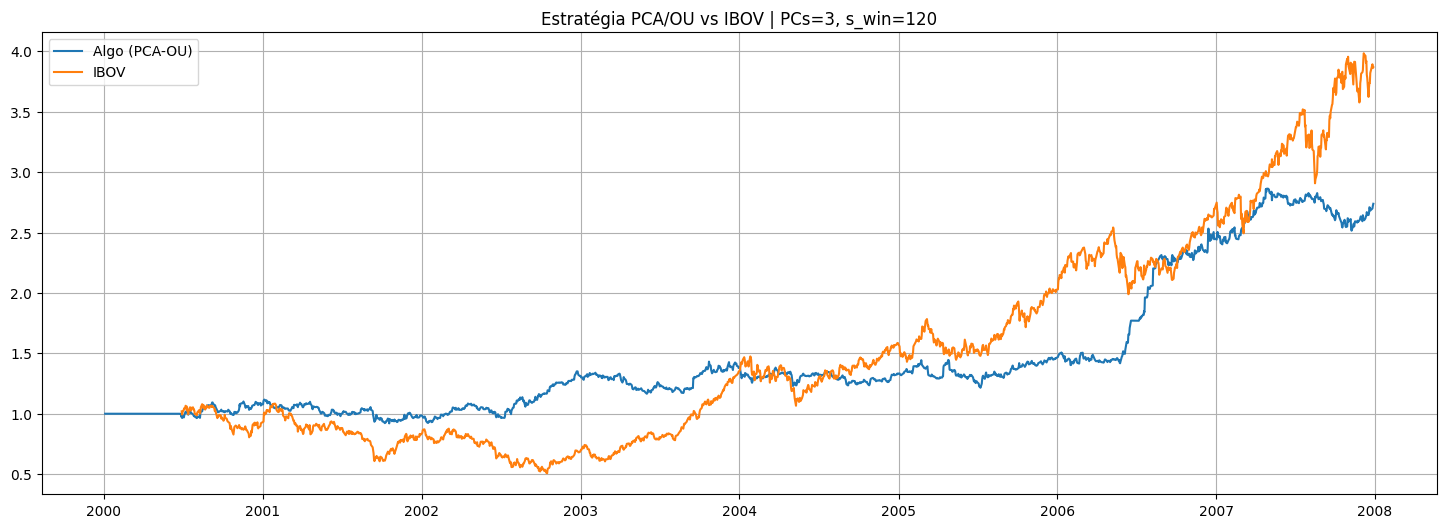

In [11]:
results3 = pca_portfolio_quantil(
    returns=returns,
    returns_bench=returns_ibov,
    benchmark="IBOV",
    num_pc=3,
    s_win=120,
    adaptive_thresholds=True,
    adaptive_window=252,
    percentile_open=0.10,
    percentile_close_short=0.45,
    percentile_close_long=0.50,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    use_drift=True,
    ma_window=60,
    plot=True
)

In [12]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net3 = results3['ret_net']
stats3 = stats_from_returns(ret_net3)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats3.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.1315 (  13.15%)
  Vol       :     0.1543 (  15.43%)
  Sharpe    :     0.8519 (  85.19%)
  MaxDD     :    -0.1763 ( -17.63%)



Tempo : 2000-06-20 00:00:00
Tempo : 2000-06-21 00:00:00
Tempo : 2000-06-22 00:00:00
Tempo : 2000-06-23 00:00:00
Tempo : 2000-06-26 00:00:00
Tempo : 2000-06-27 00:00:00
Tempo : 2000-06-28 00:00:00
Tempo : 2000-06-29 00:00:00
Tempo : 2000-06-30 00:00:00
Tempo : 2000-07-03 00:00:00
Tempo : 2000-07-04 00:00:00
Tempo : 2000-07-05 00:00:00
Tempo : 2000-07-06 00:00:00
Tempo : 2000-07-07 00:00:00
Tempo : 2000-07-10 00:00:00
Tempo : 2000-07-11 00:00:00
Tempo : 2000-07-12 00:00:00
Tempo : 2000-07-13 00:00:00
Tempo : 2000-07-14 00:00:00
Tempo : 2000-07-17 00:00:00
Tempo : 2000-07-18 00:00:00
Tempo : 2000-07-19 00:00:00
Tempo : 2000-07-20 00:00:00
Tempo : 2000-07-21 00:00:00
Tempo : 2000-07-24 00:00:00
Tempo : 2000-07-25 00:00:00
Tempo : 2000-07-26 00:00:00
Tempo : 2000-07-27 00:00:00
Tempo : 2000-07-28 00:00:00
Tempo : 2000-07-31 00:00:00
Tempo : 2000-08-01 00:00:00
Tempo : 2000-08-02 00:00:00
Tempo : 2000-08-03 00:00:00
Tempo : 2000-08-04 00:00:00
Tempo : 2000-08-07 00:00:00
Tempo : 2000-08-08 0

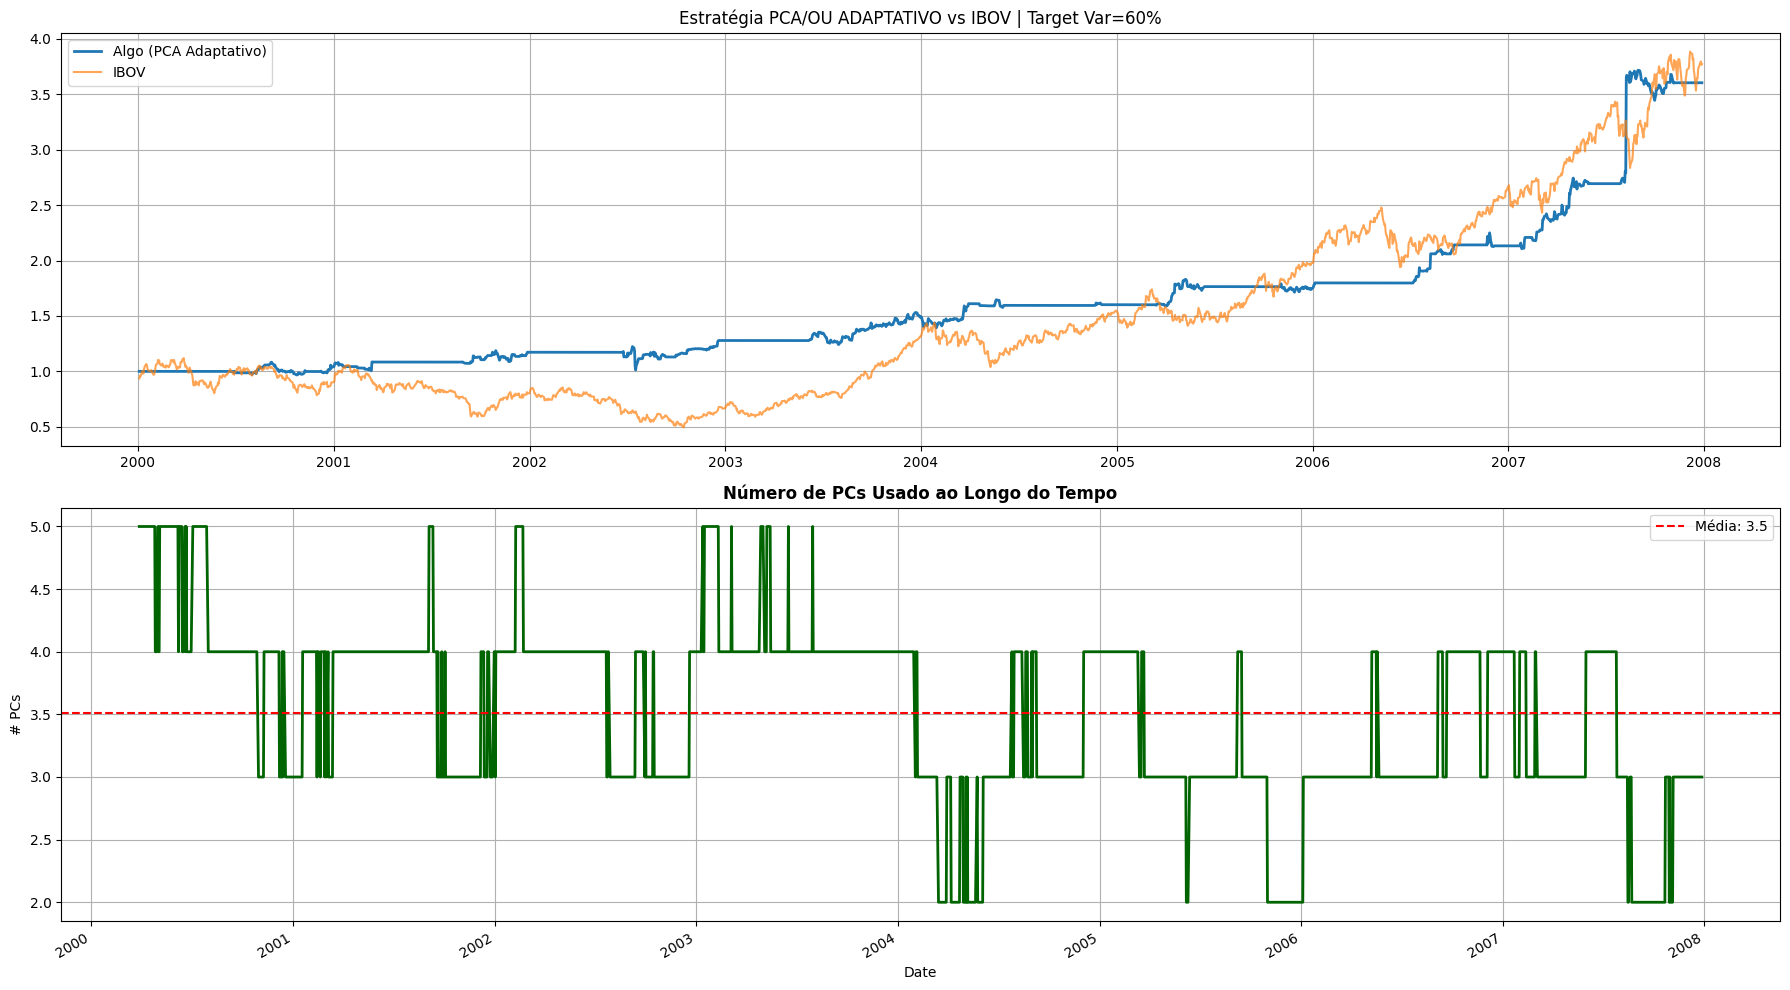

In [9]:
results4 = pca_portfolio_adaptive_pcs(
    returns = returns,
    returns_bench = returns_ibov,
    benchmark = "IBOV",
    variance_target = 0.60,  
    min_pcs = 1,
    max_pcs = 35,
    s_win = 120,
    adaptive_thresholds = False,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    use_drift = True,
    ma_window = 60,
    plot = True,
)

In [13]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net4 = results4['ret_net']
stats4 = stats_from_returns(ret_net4)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats4.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.1703 (  17.03%)
  Vol       :     0.1665 (  16.65%)
  Sharpe    :     1.0228 ( 102.28%)
  MaxDD     :    -0.1730 ( -17.30%)



Tempo : 2000-06-20 00:00:00
Tempo : 2000-06-21 00:00:00
Tempo : 2000-06-22 00:00:00
Tempo : 2000-06-23 00:00:00
Tempo : 2000-06-26 00:00:00
Tempo : 2000-06-27 00:00:00
Tempo : 2000-06-28 00:00:00
Tempo : 2000-06-29 00:00:00
Tempo : 2000-06-30 00:00:00
Tempo : 2000-07-03 00:00:00
Tempo : 2000-07-04 00:00:00
Tempo : 2000-07-05 00:00:00
Tempo : 2000-07-06 00:00:00
Tempo : 2000-07-07 00:00:00
Tempo : 2000-07-10 00:00:00
Tempo : 2000-07-11 00:00:00
Tempo : 2000-07-12 00:00:00
Tempo : 2000-07-13 00:00:00
Tempo : 2000-07-14 00:00:00
Tempo : 2000-07-17 00:00:00
Tempo : 2000-07-18 00:00:00
Tempo : 2000-07-19 00:00:00
Tempo : 2000-07-20 00:00:00
Tempo : 2000-07-21 00:00:00
Tempo : 2000-07-24 00:00:00
Tempo : 2000-07-25 00:00:00
Tempo : 2000-07-26 00:00:00
Tempo : 2000-07-27 00:00:00
Tempo : 2000-07-28 00:00:00
Tempo : 2000-07-31 00:00:00
Tempo : 2000-08-01 00:00:00
Tempo : 2000-08-02 00:00:00
Tempo : 2000-08-03 00:00:00
Tempo : 2000-08-04 00:00:00
Tempo : 2000-08-07 00:00:00
Tempo : 2000-08-08 0

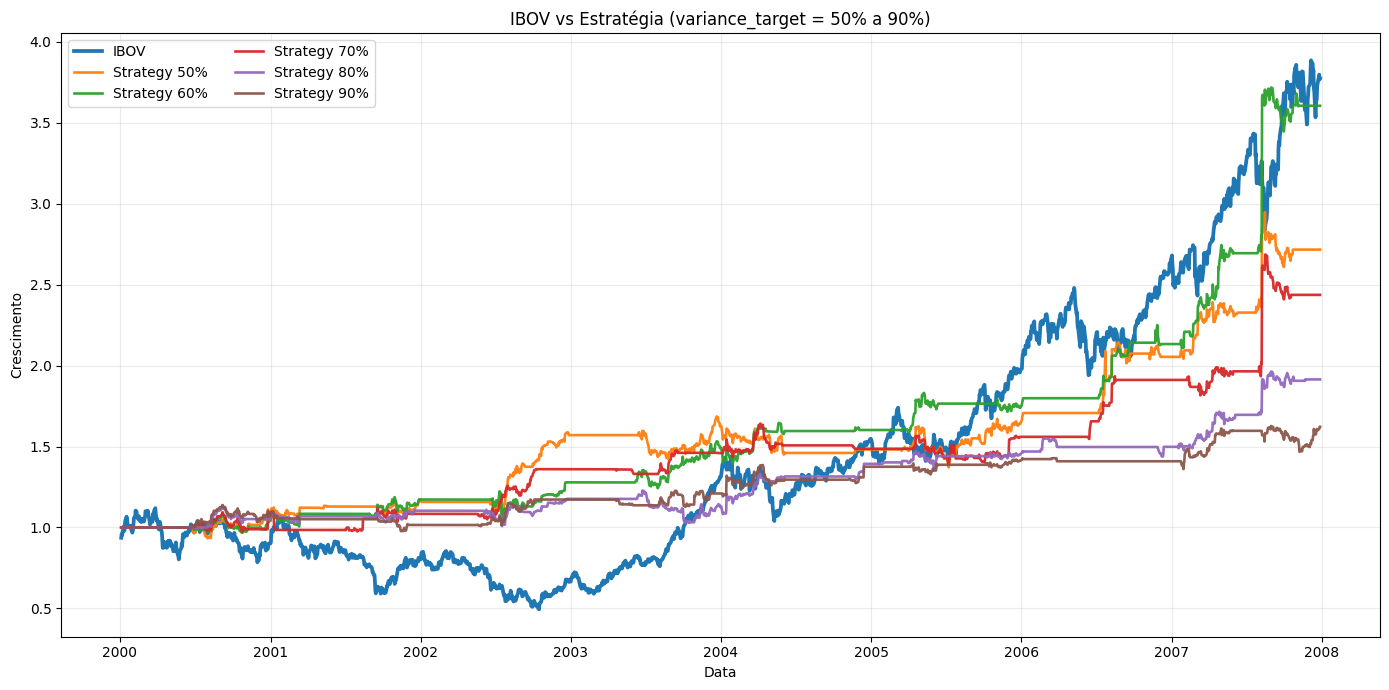

In [10]:
targets = [0.50, 0.60, 0.70, 0.80, 0.90]

curves_algo = []
bench_eq = None

for vt in targets:
    res = pca_portfolio_adaptive_pcs(
        returns=returns,
        returns_bench=returns_ibov,
        benchmark="IBOV",
        variance_target=vt,
        min_pcs=1,
        max_pcs=35,
        s_win=120,
        adaptive_thresholds=False,
        # thresholds fixos
        sbo=1.25, sso=1.25, sbc=0.50, ssc=0.50,
        eps_cost=0.0005,
        rebalanceamento_dias=1,
        use_drift=True,
        ma_window=60,
        plot=False,
    )

    s = res["cumret_algo"].copy()
    s.name = f"Strategy {int(vt*100)}%"
    curves_algo.append(s)

    # ---- benchmark
    if bench_eq is None:
        b = res["cumret_bench"]
        if isinstance(b, pd.DataFrame):
            b = b.iloc[:, 0]  # primeira (e única) coluna
        bench_eq = b.copy()
        bench_eq.name = "IBOV"

# junta tudo (alinha pelo índice)
df = pd.concat([bench_eq, *curves_algo], axis=1).dropna()

# -----------------------------
# plot
# -----------------------------
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["IBOV"], linewidth=2.7, label="IBOV")  # destaque pro benchmark

for col in df.columns:
    if col != "IBOV":
        plt.plot(df.index, df[col], linewidth=1.9, alpha=0.95, label=col)

plt.title("IBOV vs Estratégia (variance_target = 50% a 90%)")
plt.xlabel("Data")
plt.ylabel("Crescimento")
plt.grid(True, alpha=0.25)
plt.legend(ncol=2, frameon=True)
plt.tight_layout()
plt.show()

Tempo : 2000-06-20 00:00:00
Tempo : 2000-06-21 00:00:00
Tempo : 2000-06-22 00:00:00
Tempo : 2000-06-23 00:00:00
Tempo : 2000-06-26 00:00:00
Tempo : 2000-06-27 00:00:00
Tempo : 2000-06-28 00:00:00
Tempo : 2000-06-29 00:00:00
Tempo : 2000-06-30 00:00:00
Tempo : 2000-07-03 00:00:00
Tempo : 2000-07-04 00:00:00
Tempo : 2000-07-05 00:00:00
Tempo : 2000-07-06 00:00:00
Tempo : 2000-07-07 00:00:00
Tempo : 2000-07-10 00:00:00
Tempo : 2000-07-11 00:00:00
Tempo : 2000-07-12 00:00:00
Tempo : 2000-07-13 00:00:00
Tempo : 2000-07-14 00:00:00
Tempo : 2000-07-17 00:00:00
Tempo : 2000-07-18 00:00:00
Tempo : 2000-07-19 00:00:00
Tempo : 2000-07-20 00:00:00
Tempo : 2000-07-21 00:00:00
Tempo : 2000-07-24 00:00:00
Tempo : 2000-07-25 00:00:00
Tempo : 2000-07-26 00:00:00
Tempo : 2000-07-27 00:00:00
Tempo : 2000-07-28 00:00:00
Tempo : 2000-07-31 00:00:00
Tempo : 2000-08-01 00:00:00
Tempo : 2000-08-02 00:00:00
Tempo : 2000-08-03 00:00:00
Tempo : 2000-08-04 00:00:00
Tempo : 2000-08-07 00:00:00
Tempo : 2000-08-08 0

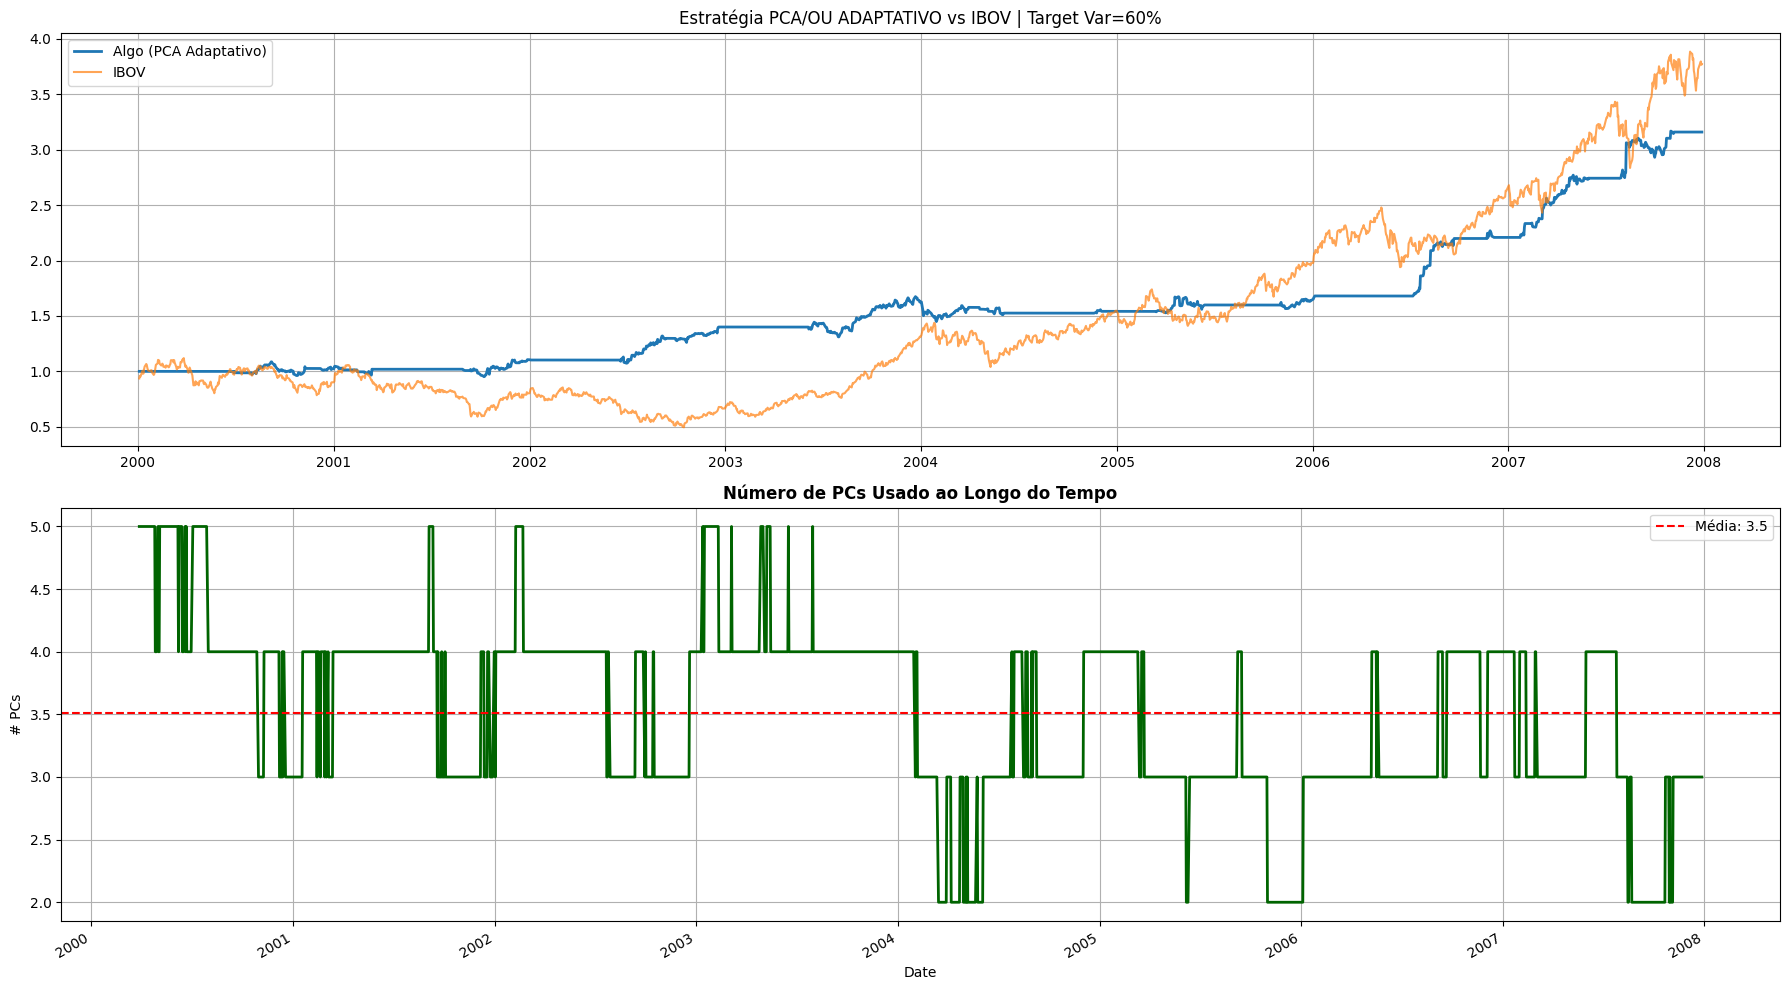

In [14]:
results5 = pca_portfolio_adaptive_pcs(
    returns = returns,
    returns_bench = returns_ibov,
    benchmark = "IBOV",
    variance_target = 0.60,  
    min_pcs = 1,
    max_pcs = 35,
    s_win = 120,
    adaptive_thresholds = True,
    adaptive_window = 252,
    percentile_open = 0.15,
    percentile_close_short = 0.35,
    percentile_close_long = 0.45,
    # thresholds fixos
    sbo = 1.25,
    sso = 1.25,
    sbc = 0.50,
    ssc = 0.50,
    eps_cost = 0.0005,
    rebalanceamento_dias = 1,
    use_drift = True,
    ma_window = 60,
    plot = True,
)

In [15]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net5 = results5['ret_net']
stats5 = stats_from_returns(ret_net5)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2007)")
print("="*70)
for k, v in stats5.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


PERFORMANCE DA ESTRATÉGIA (1999-2007)
  CAGR      :     0.1515 (  15.15%)
  Vol       :     0.1147 (  11.47%)
  Sharpe    :     1.3207 ( 132.07%)
  MaxDD     :    -0.1347 ( -13.47%)



### Teste para longo prazo

In [19]:
# Carregar dados
start_date2 = "2000-01-03"
end_date2 = "2025-12-31"

data_longa = pd.read_csv("precos_1997_2025.csv", index_col=0)
data_longa.index = pd.to_datetime(data_longa.index)
data_longa = data_longa.sort_index()

returns_longa = data_longa.pct_change()
returns_longa.dropna(inplace=True,axis=0, how='all')
returns_longa.dropna(inplace=True,axis=1, how='any')
#returns = returns.loc[start_date:end_date]

# Ibovespa no Yahoo é ^BVSP
data_ibov_longa = yf.download("^BVSP", start=start_date2, end=end_date2, auto_adjust=True, progress=False)["Close"]
data_ibov_longa.index = pd.to_datetime(data_ibov_longa.index).tz_localize(None)
data_ibov_longa = data_ibov_longa.sort_index()

returns_ibov_longa = data_ibov_longa.pct_change().dropna()
returns_ibov_longa.name = "IBOV"

# Garantir que ambos os DataFrames tenham índices coerentes e ordenados (sem timezone)
returns_longa.index     = pd.to_datetime(returns_longa.index).tz_localize(None)
returns_ibov_longa.index = pd.to_datetime(returns_ibov_longa.index).tz_localize(None)
returns_longa     = returns_longa.sort_index()
returns_ibov_longa = returns_ibov_longa.sort_index()

C:\Users\savio\AppData\Local\Temp\ipykernel_12668\1297118825.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_longa = data_longa.pct_change()


In [20]:
bad_tickers2 = ["CPFE3.SA"]

for col in data_longa.columns:
    p = data_longa[col]
    if p.min() <= 0:
        bad_tickers2.append(col)
        continue
    if (p.max() / p.min()) > 1e3:  # variação absurda de escala
        bad_tickers2.append(col)

bad_tickers2

['CPFE3.SA',
 'AZUL4.SA',
 'BRKM5.SA',
 'CMIG4.SA',
 'GGBR4.SA',
 'LREN3.SA',
 'RADL3.SA',
 'UGPA3.SA']

In [21]:
data_longa = data_longa.drop(columns=bad_tickers2, errors="ignore")
returns_longa = returns_longa.drop(columns=bad_tickers2, errors="ignore")

tickers2 = data_longa.columns.tolist()
len(tickers2)

73

Tempo : 2000-03-28 00:00:00
Tempo : 2000-03-29 00:00:00
Tempo : 2000-03-30 00:00:00
Tempo : 2000-03-31 00:00:00
Tempo : 2000-04-03 00:00:00
Tempo : 2000-04-04 00:00:00
Tempo : 2000-04-05 00:00:00
Tempo : 2000-04-06 00:00:00
Tempo : 2000-04-07 00:00:00
Tempo : 2000-04-10 00:00:00
Tempo : 2000-04-11 00:00:00
Tempo : 2000-04-12 00:00:00
Tempo : 2000-04-13 00:00:00
Tempo : 2000-04-14 00:00:00
Tempo : 2000-04-17 00:00:00
Tempo : 2000-04-18 00:00:00
Tempo : 2000-04-19 00:00:00
Tempo : 2000-04-20 00:00:00
Tempo : 2000-04-21 00:00:00
Tempo : 2000-04-24 00:00:00
Tempo : 2000-04-25 00:00:00
Tempo : 2000-04-26 00:00:00
Tempo : 2000-04-27 00:00:00
Tempo : 2000-04-28 00:00:00
Tempo : 2000-05-01 00:00:00
Tempo : 2000-05-02 00:00:00
Tempo : 2000-05-03 00:00:00
Tempo : 2000-05-04 00:00:00
Tempo : 2000-05-05 00:00:00
Tempo : 2000-05-08 00:00:00
Tempo : 2000-05-09 00:00:00
Tempo : 2000-05-10 00:00:00
Tempo : 2000-05-11 00:00:00
Tempo : 2000-05-12 00:00:00
Tempo : 2000-05-15 00:00:00
Tempo : 2000-05-16 0

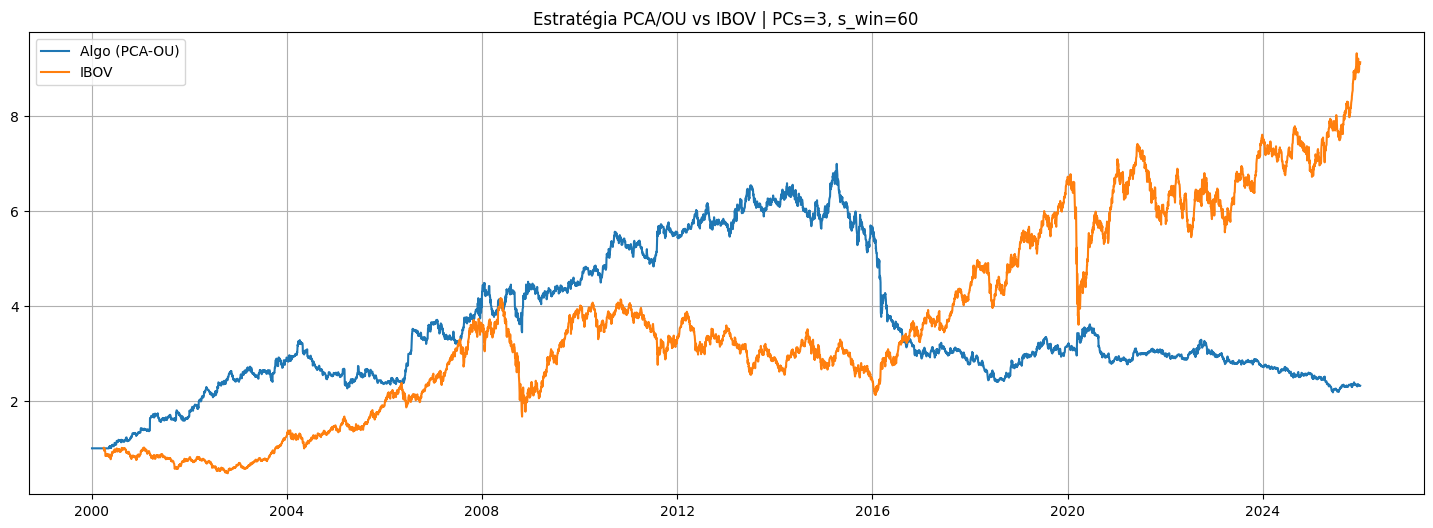

In [ ]:
# Melhor longo (sem drift)

results_long_0 = pca_portfolio_hedge(
    returns=returns_longa,
    returns_bench=returns_ibov_longa,
    benchmark="IBOV",
    num_pc=3,
    s_win=60,
    #s_win=120,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    #kappa_min=8.4, # padrão
    #kappa_min=5.0,
    kappa_min=10.0,
    plot=True,
    use_drift=False
)


PERFORMANCE DA ESTRATÉGIA (1999-2025)
  CAGR      :     0.0330 (   3.30%)
  Vol       :     0.1654 (  16.54%)
  Sharpe    :     0.1996 (  19.96%)
  MaxDD     :    -0.6884 ( -68.84%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


 Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0031 (0.31%)
  Alpha anualizado (excesso de retorno):  0.0464 (4.64%)
  Alpha diário médio:                      0.000184

  Beta médio (|valor|):                    0.0313
  Beta máximo (|valor|):                   0.0505 (fator: eig3)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ⚠️  Alpha marginal (4.64%/ano)


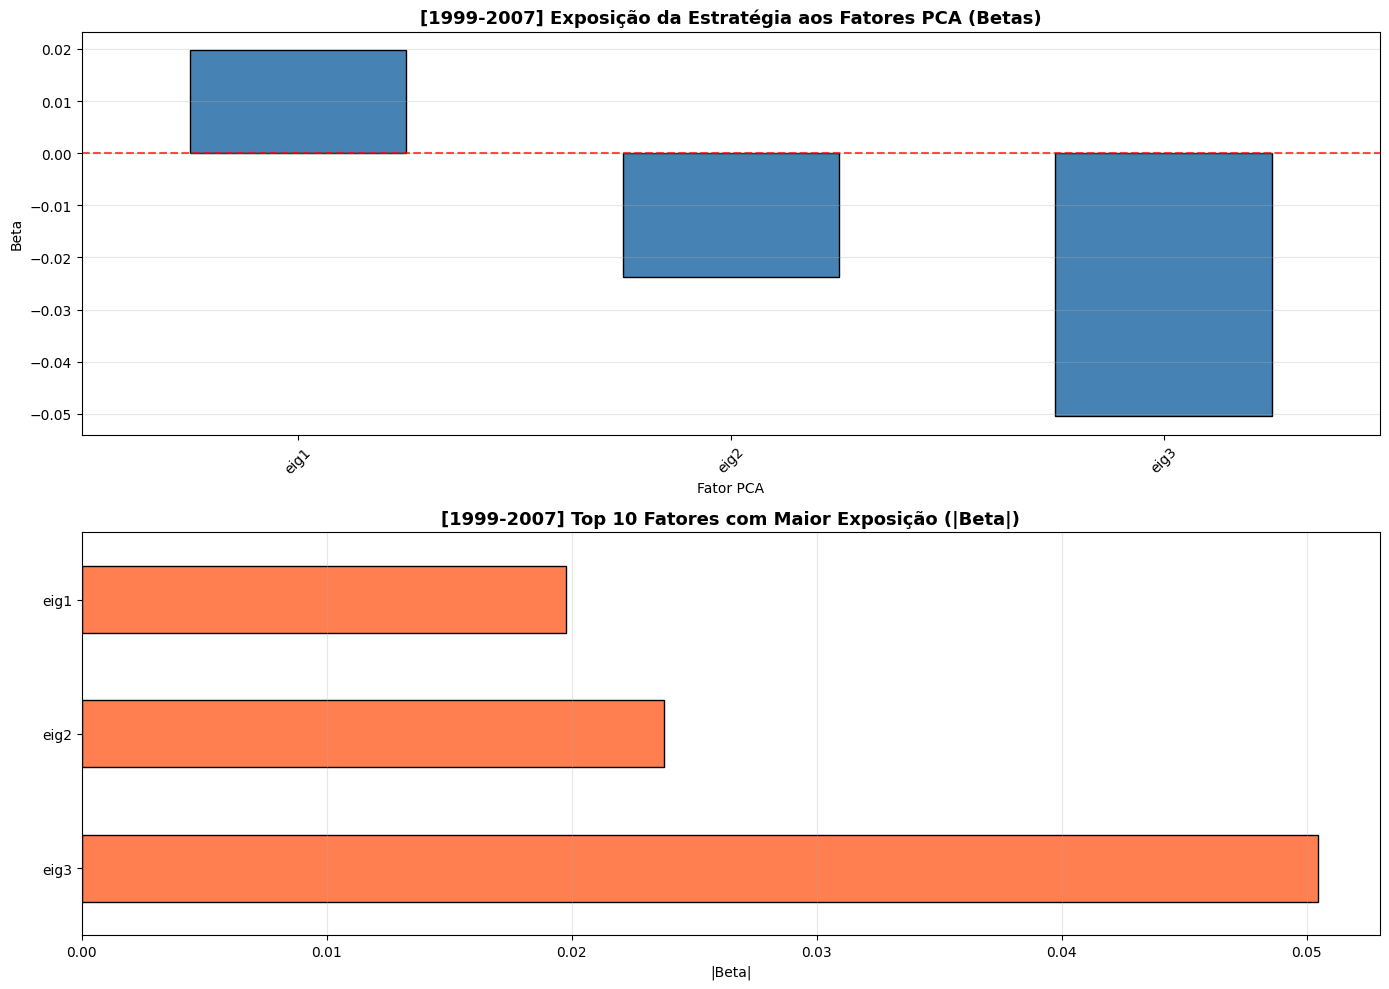


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1997-2002
  CAGR      :     0.3310 (  33.10%)
  Vol       :     0.1968 (  19.68%)
  Sharpe    :     1.6817 ( 168.17%)
  MaxDD     :    -0.1218 ( -12.18%)

Subperíodo: 2003-2007
  CAGR      :     0.1019 (  10.19%)
  Vol       :     0.1887 (  18.87%)
  Sharpe    :     0.5400 (  54.00%)
  MaxDD     :    -0.3101 ( -31.01%)

Subperíodo: 2008-2012
  CAGR      :     0.0773 (   7.73%)
  Vol       :     0.1541 (  15.41%)
  Sharpe    :     0.5018 (  50.18%)
  MaxDD     :    -0.2318 ( -23.18%)

Subperíodo: 2013-2019
  CAGR      :    -0.0830 (  -8.30%)
  Vol       :     0.1703 (  17.03%)
  Sharpe    :    -0.4873 ( -48.73%)
  MaxDD     :    -0.6568 ( -65.68%)

Subperíodo: 2020-2025
  CAGR      :    -0.0500 (  -5.00%)
  Vol       :     0.1237 (  12.37%)
  Sharpe    :    -0.4037 ( -40.37%)
  MaxDD   

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net_long = results_long_0['ret_net']
stats_long = stats_from_returns(ret_net_long)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2025)")
print("="*70)
for k, v in stats_long.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results_long_0['algo_weights'],
    betas=results_long_0['betas'],
    ret_net=results_long_0['ret_net'],
    Factor_PCA=results_long_0['Factor_PCA'],
    pcs=results_long_0['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

Tempo : 2000-06-20 00:00:00
Tempo : 2000-06-21 00:00:00
Tempo : 2000-06-22 00:00:00
Tempo : 2000-06-23 00:00:00
Tempo : 2000-06-26 00:00:00
Tempo : 2000-06-27 00:00:00
Tempo : 2000-06-28 00:00:00
Tempo : 2000-06-29 00:00:00
Tempo : 2000-06-30 00:00:00
Tempo : 2000-07-03 00:00:00
Tempo : 2000-07-04 00:00:00
Tempo : 2000-07-05 00:00:00
Tempo : 2000-07-06 00:00:00
Tempo : 2000-07-07 00:00:00
Tempo : 2000-07-10 00:00:00
Tempo : 2000-07-11 00:00:00
Tempo : 2000-07-12 00:00:00
Tempo : 2000-07-13 00:00:00
Tempo : 2000-07-14 00:00:00
Tempo : 2000-07-17 00:00:00
Tempo : 2000-07-18 00:00:00
Tempo : 2000-07-19 00:00:00
Tempo : 2000-07-20 00:00:00
Tempo : 2000-07-21 00:00:00
Tempo : 2000-07-24 00:00:00
Tempo : 2000-07-25 00:00:00
Tempo : 2000-07-26 00:00:00
Tempo : 2000-07-27 00:00:00
Tempo : 2000-07-28 00:00:00
Tempo : 2000-07-31 00:00:00
Tempo : 2000-08-01 00:00:00
Tempo : 2000-08-02 00:00:00
Tempo : 2000-08-03 00:00:00
Tempo : 2000-08-04 00:00:00
Tempo : 2000-08-07 00:00:00
Tempo : 2000-08-08 0

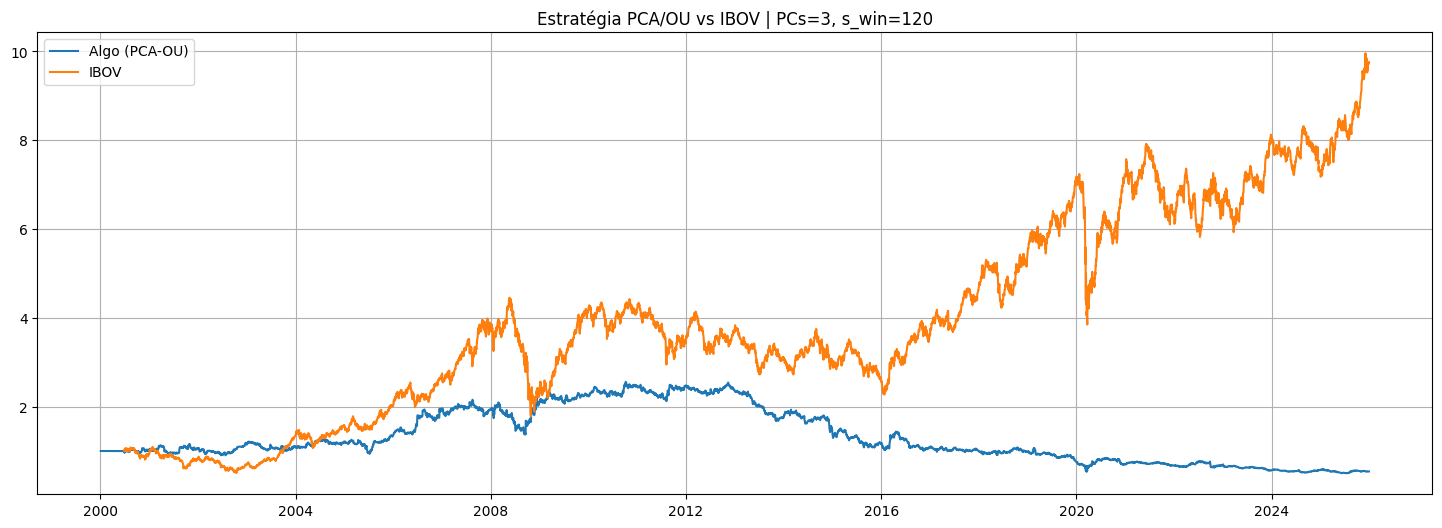

In [ ]:
# Melhor longo (com drift)

results_long = pca_portfolio_hedge(
    returns=returns_longa,
    returns_bench=returns_ibov_longa,
    benchmark="IBOV",
    num_pc=3,
    s_win=120,
    ma_window=60,
    sbo=1.25,           # buy-to-open se s < -sbo
    sso=1.25,           # sell-to-open se s > +sso
    sbc=0.50,           # close short se s < +sbc
    ssc=0.50,          # close long se s > -ssc
    eps_cost=0.0005,
    rebalanceamento_dias=1,
    #kappa_min=8.4, # padrão
    #kappa_min=5.0,
    kappa_min=10.0,
    plot=True,
    use_drift=True
)


PERFORMANCE DA ESTRATÉGIA (1999-2025)
  CAGR      :    -0.0235 (  -2.35%)
  Vol       :     0.1844 (  18.44%)
  Sharpe    :    -0.1277 ( -12.77%)
  MaxDD     :    -0.8052 ( -80.52%)


🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 
ANÁLISE DE NEUTRALIDADE DA ESTRATÉGIA
🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 🔍 


 Regredindo PnL contra fatores...

REGRESSÃO: RETORNO DA ESTRATÉGIA vs FATORES PCA
  R² (variância explicada por fatores): 0.0235 (2.35%)
  Alpha anualizado (excesso de retorno):  -0.0207 (-2.07%)
  Alpha diário médio:                      -0.000082

  Beta médio (|valor|):                    0.0664
  Beta máximo (|valor|):                   0.0936 (fator: eig1)

📊 Interpretação:
  ✅ EXCELENTE: R² < 5% → Estratégia é genuinamente market-neutral!
     A maior parte do retorno vem de alpha idiossincrático.

  ❌ Alpha negativo (-2.07%/ano) → Destruição de valor!


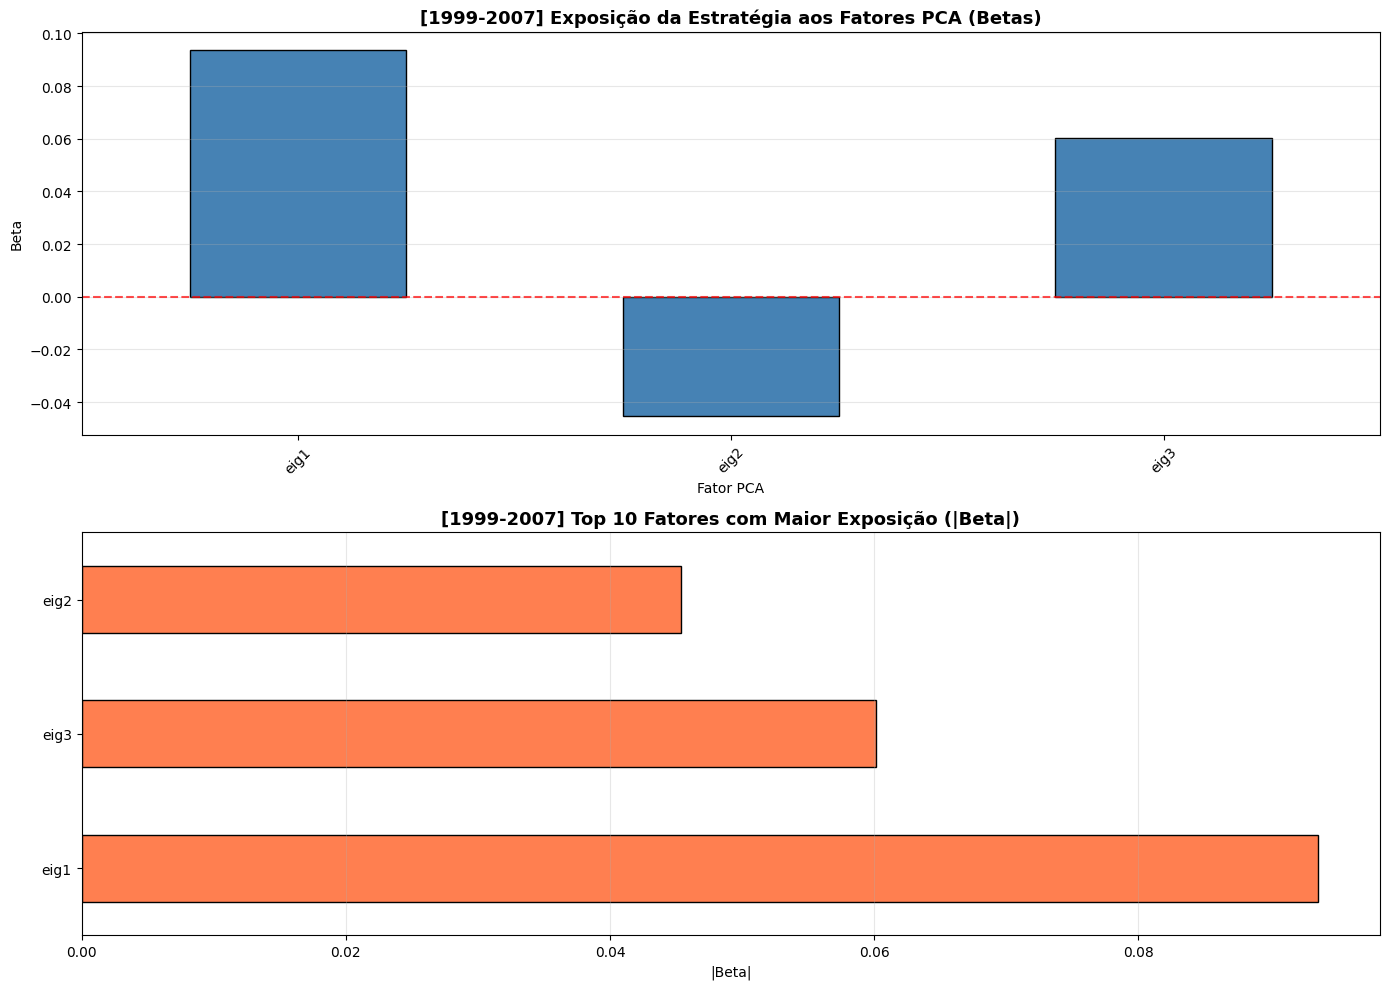


✅ Análise concluída!


📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 
ANÁLISE POR SUBPERÍODOS
📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 📅 


Subperíodo: 1997-2002
  CAGR      :     0.0449 (   4.49%)
  Vol       :     0.1586 (  15.86%)
  Sharpe    :     0.2829 (  28.29%)
  MaxDD     :    -0.2212 ( -22.12%)

Subperíodo: 2003-2007
  CAGR      :     0.1078 (  10.78%)
  Vol       :     0.1851 (  18.51%)
  Sharpe    :     0.5823 (  58.23%)
  MaxDD     :    -0.2550 ( -25.50%)

Subperíodo: 2008-2012
  CAGR      :     0.0433 (   4.33%)
  Vol       :     0.1942 (  19.42%)
  Sharpe    :     0.2227 (  22.27%)
  MaxDD     :    -0.3451 ( -34.51%)

Subperíodo: 2013-2019
  CAGR      :    -0.1515 ( -15.15%)
  Vol       :     0.1811 (  18.11%)
  Sharpe    :    -0.8361 ( -83.61%)
  MaxDD     :    -0.6766 ( -67.66%)

Subperíodo: 2020-2025
  CAGR      :    -0.0566 (  -5.66%)
  Vol       :     0.1913 (  19.13%)
  Sharpe    :    -0.2957 ( -29.57%)
  MaxDD   

In [ ]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_net_long = results_long['ret_net']
stats_long = stats_from_returns(ret_net_long)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2025)")
print("="*70)
for k, v in stats_long.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")

# =============================================================================
# 4. ANÁLISE DE NEUTRALIDADE
# =============================================================================

analysis_results = analyze_strategy(
    algo_weights=results_long['algo_weights'],
    betas=results_long['betas'],
    ret_net=results_long['ret_net'],
    Factor_PCA=results_long['Factor_PCA'],
    pcs=results_long['pcs'],
    plot=True,
    title_prefix="[1999-2007] "
)

In [22]:
adj_map = results_long['adj_map']
adj_map

{'BBAS3.SA': 0.05603364403449538,
 'BBDC3.SA': 0.30906314005918595,
 'CSNA3.SA': 0.4013582354220288,
 'CYRE3.SA': 0.26166522703770956,
 'GOAU4.SA': 0.06796417190229809,
 'ITSA4.SA': -0.6711503060901933,
 'PETR3.SA': -0.25713989420781386,
 'PETR4.SA': -0.20741231332283666,
 'SBSP3.SA': -0.05124570557281411,
 'USIM5.SA': 0.09964691015138126,
 'VALE3.SA': 0.03540842400929735,
 'VIVT3.SA': -0.19155889309884808}

### Identificando motivo das quedas no longo prazo

In [23]:
# Vou criar funções de diagnóstico para analisar:
# 1. Autovalores da decomposição PCA ao longo do tempo
# 2. Variância explicada pelos fatores
# 3. Correlação dos fatores com o mercado
# 4. Distribuição dos s-scores
# 5. Qualidade do ajuste OU (kappa, sigma_eq)

def diagnose_pca_factors(returns, window_pca=60, n_factors=10):
    """
    Analisa a evolução dos autovalores e fatores PCA ao longo do tempo
    """
    dates = returns.index
    
    # Armazenar métricas ao longo do tempo
    eigenvalues_over_time = []
    variance_explained = []
    eigenvalue_ratios = []
    
    for i in range(window_pca, len(dates)):
        t_hist = dates[i - window_pca : i]
        t = dates[i]
        
        Rw = returns.loc[t_hist]
        Zw = (Rw - Rw.mean()) / Rw.std(ddof=1)
        Zw = Zw.dropna(axis=1, how='any')
        
        if Zw.shape[1] < n_factors + 1:
            continue
            
        # Correlação e autovalores
        C = Zw.corr()
        evals, _ = np.linalg.eigh(C.values)
        evals = np.sort(evals)[::-1]  # decrescente
        
        # Guardar informações
        eigenvalues_over_time.append({
            'date': t,
            **{f'eig_{j+1}': evals[j] if j < len(evals) else np.nan 
               for j in range(n_factors)}
        })
        
        # Variância explicada
        var_exp = evals[:n_factors].sum() / evals.sum()
        variance_explained.append({'date': t, 'var_explained': var_exp})
        
        # Razão entre 1º e 2º autovalor (market factor dominance)
        if len(evals) >= 2:
            eigenvalue_ratios.append({
                'date': t, 
                'eig1_eig2_ratio': evals[0] / evals[1],
                'eig1_proportion': evals[0] / evals.sum()
            })
    
    df_eigs = pd.DataFrame(eigenvalues_over_time).set_index('date')
    df_var = pd.DataFrame(variance_explained).set_index('date')
    df_ratios = pd.DataFrame(eigenvalue_ratios).set_index('date')
    
    return df_eigs, df_var, df_ratios


def diagnose_ou_parameters(returns, factors, s_win=60, n_factors=10, kappa_min=5.0):
    """
    Analisa a evolução dos parâmetros OU (kappa, sigma_eq, m) ao longo do tempo
    """
    stocks = list(returns.columns)
    pcs = [f"eig{i+1}" for i in range(n_factors)]
    usable_index = returns.iloc[s_win:].index
    
    ou_stats = []
    
    for t in usable_index:
        ret = returns.loc[:t].iloc[-s_win:].copy()
        ret = (ret - ret.mean()) / ret.std(ddof=1)
        
        factor = factors.loc[:t].iloc[-s_win:].copy()
        factor = (factor - factor.mean()) / factor.std(ddof=1)
        
        if factor[pcs].isnull().any().any():
            continue
        
        # Estatísticas para este dia
        kappas = []
        sigma_eqs = []
        ms = []
        valid_stocks = 0
        
        for stock in stocks:
            y_ser = ret[stock]
            df = pd.concat([y_ser.rename("y"), factor[pcs]], axis=1).dropna()
            
            if len(df) < 30:
                continue
                
            X = df.drop(columns=["y"]).values
            y = df["y"].values
            
            # Regressão
            model = LinearRegression().fit(X, y)
            eps = y - model.predict(X)
            
            # OU
            Xk = np.cumsum(eps)
            if len(Xk) < 2:
                continue
                
            X_ou = Xk[:-1].reshape(-1, 1)
            y_ou = Xk[1:]
            
            model_ou = LinearRegression().fit(X_ou, y_ou)
            a = float(model_ou.intercept_)
            b = float(model_ou.coef_[0])
            
            if not (1e-6 < b < 1):
                continue
                
            zeta = y_ou - model_ou.predict(X_ou)
            var_zeta = float(np.var(zeta, ddof=1))
            
            if var_zeta <= 0:
                continue
                
            m = a / (1.0 - b)
            kappa_ann = -np.log(b) * 252
            sigma_eq = np.sqrt(var_zeta / (1.0 - b**2))
            
            if kappa_ann > kappa_min:
                kappas.append(kappa_ann)
                sigma_eqs.append(sigma_eq)
                ms.append(m)
                valid_stocks += 1
        
        if valid_stocks > 0:
            ou_stats.append({
                'date': t,
                'mean_kappa': np.mean(kappas),
                'median_kappa': np.median(kappas),
                'mean_sigma_eq': np.mean(sigma_eqs),
                'std_m': np.std(ms),
                'mean_abs_m': np.mean(np.abs(ms)),
                'valid_stocks': valid_stocks
            })
    
    return pd.DataFrame(ou_stats).set_index('date')


def plot_diagnostics(df_eigs, df_var, df_ratios, df_ou, returns_ibov):
    """
    Cria visualizações para diagnóstico
    """
    fig, axes = plt.subplots(5, 1, figsize=(18, 20))
    
    # 1. Primeiros 5 autovalores ao longo do tempo
    ax = axes[0]
    for i in range(5):
        col = f'eig_{i+1}'
        if col in df_eigs.columns:
            ax.plot(df_eigs.index, df_eigs[col], label=f'λ{i+1}', alpha=0.7)
    ax.set_title('Evolução dos Primeiros 5 Autovalores', fontsize=14, fontweight='bold')
    ax.set_ylabel('Autovalor')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.axvspan('2016', '2020', alpha=0.2, color='red', label='Período Problemático')
    
    # 2. Razão entre autovalores e proporção do 1º
    ax = axes[1]
    ax2 = ax.twinx()
    
    ax.plot(df_ratios.index, df_ratios['eig1_eig2_ratio'], 
            color='blue', label='λ1/λ2 (Dominância Mercado)', linewidth=2)
    ax2.plot(df_ratios.index, df_ratios['eig1_proportion'], 
             color='green', label='λ1 / Σλ (% Var.)', linewidth=2, alpha=0.7)
    
    ax.set_ylabel('Razão λ1/λ2', color='blue')
    ax2.set_ylabel('Proporção λ1', color='green')
    ax.set_title('Dominância do Fator de Mercado (λ1)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='blue')
    ax2.tick_params(axis='y', labelcolor='green')
    ax.grid(True, alpha=0.3)
    ax.axvspan('2016', '2020', alpha=0.2, color='red')
    
    # 3. Variância explicada pelos n fatores
    ax = axes[2]
    ax.plot(df_var.index, df_var['var_explained'] * 100, linewidth=2, color='purple')
    ax.set_title('Variância Explicada pelos Fatores PCA (%)', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Variância')
    ax.grid(True, alpha=0.3)
    ax.axvspan('2016', '2020', alpha=0.2, color='red')
    ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
    ax.legend()
    
    # 4. Parâmetros OU ao longo do tempo
    ax = axes[3]
    ax2 = ax.twinx()
    
    ax.plot(df_ou.index, df_ou['mean_kappa'], 
            color='orange', label='Kappa Médio', linewidth=2)
    ax2.plot(df_ou.index, df_ou['valid_stocks'], 
             color='brown', label='Ações Válidas', linewidth=2, alpha=0.7)
    
    ax.set_ylabel('Kappa (velocidade reversão)', color='orange')
    ax2.set_ylabel('# Ações Válidas', color='brown')
    ax.set_title('Parâmetros do Processo OU', fontsize=14, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='orange')
    ax2.tick_params(axis='y', labelcolor='brown')
    ax.grid(True, alpha=0.3)
    ax.axvspan('2016', '2020', alpha=0.2, color='red')
    
    # 5. Ibovespa para contexto
    ax = axes[4]
    cumret_ibov = (1 + returns_ibov).cumprod()
    ax.plot(cumret_ibov.index, cumret_ibov, color='black', linewidth=2)
    ax.set_title('Ibovespa (Referência)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Retorno Acumulado')
    ax.set_xlabel('Data')
    ax.grid(True, alpha=0.3)
    ax.axvspan('2016', '2020', alpha=0.2, color='red', label='Período Problemático')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

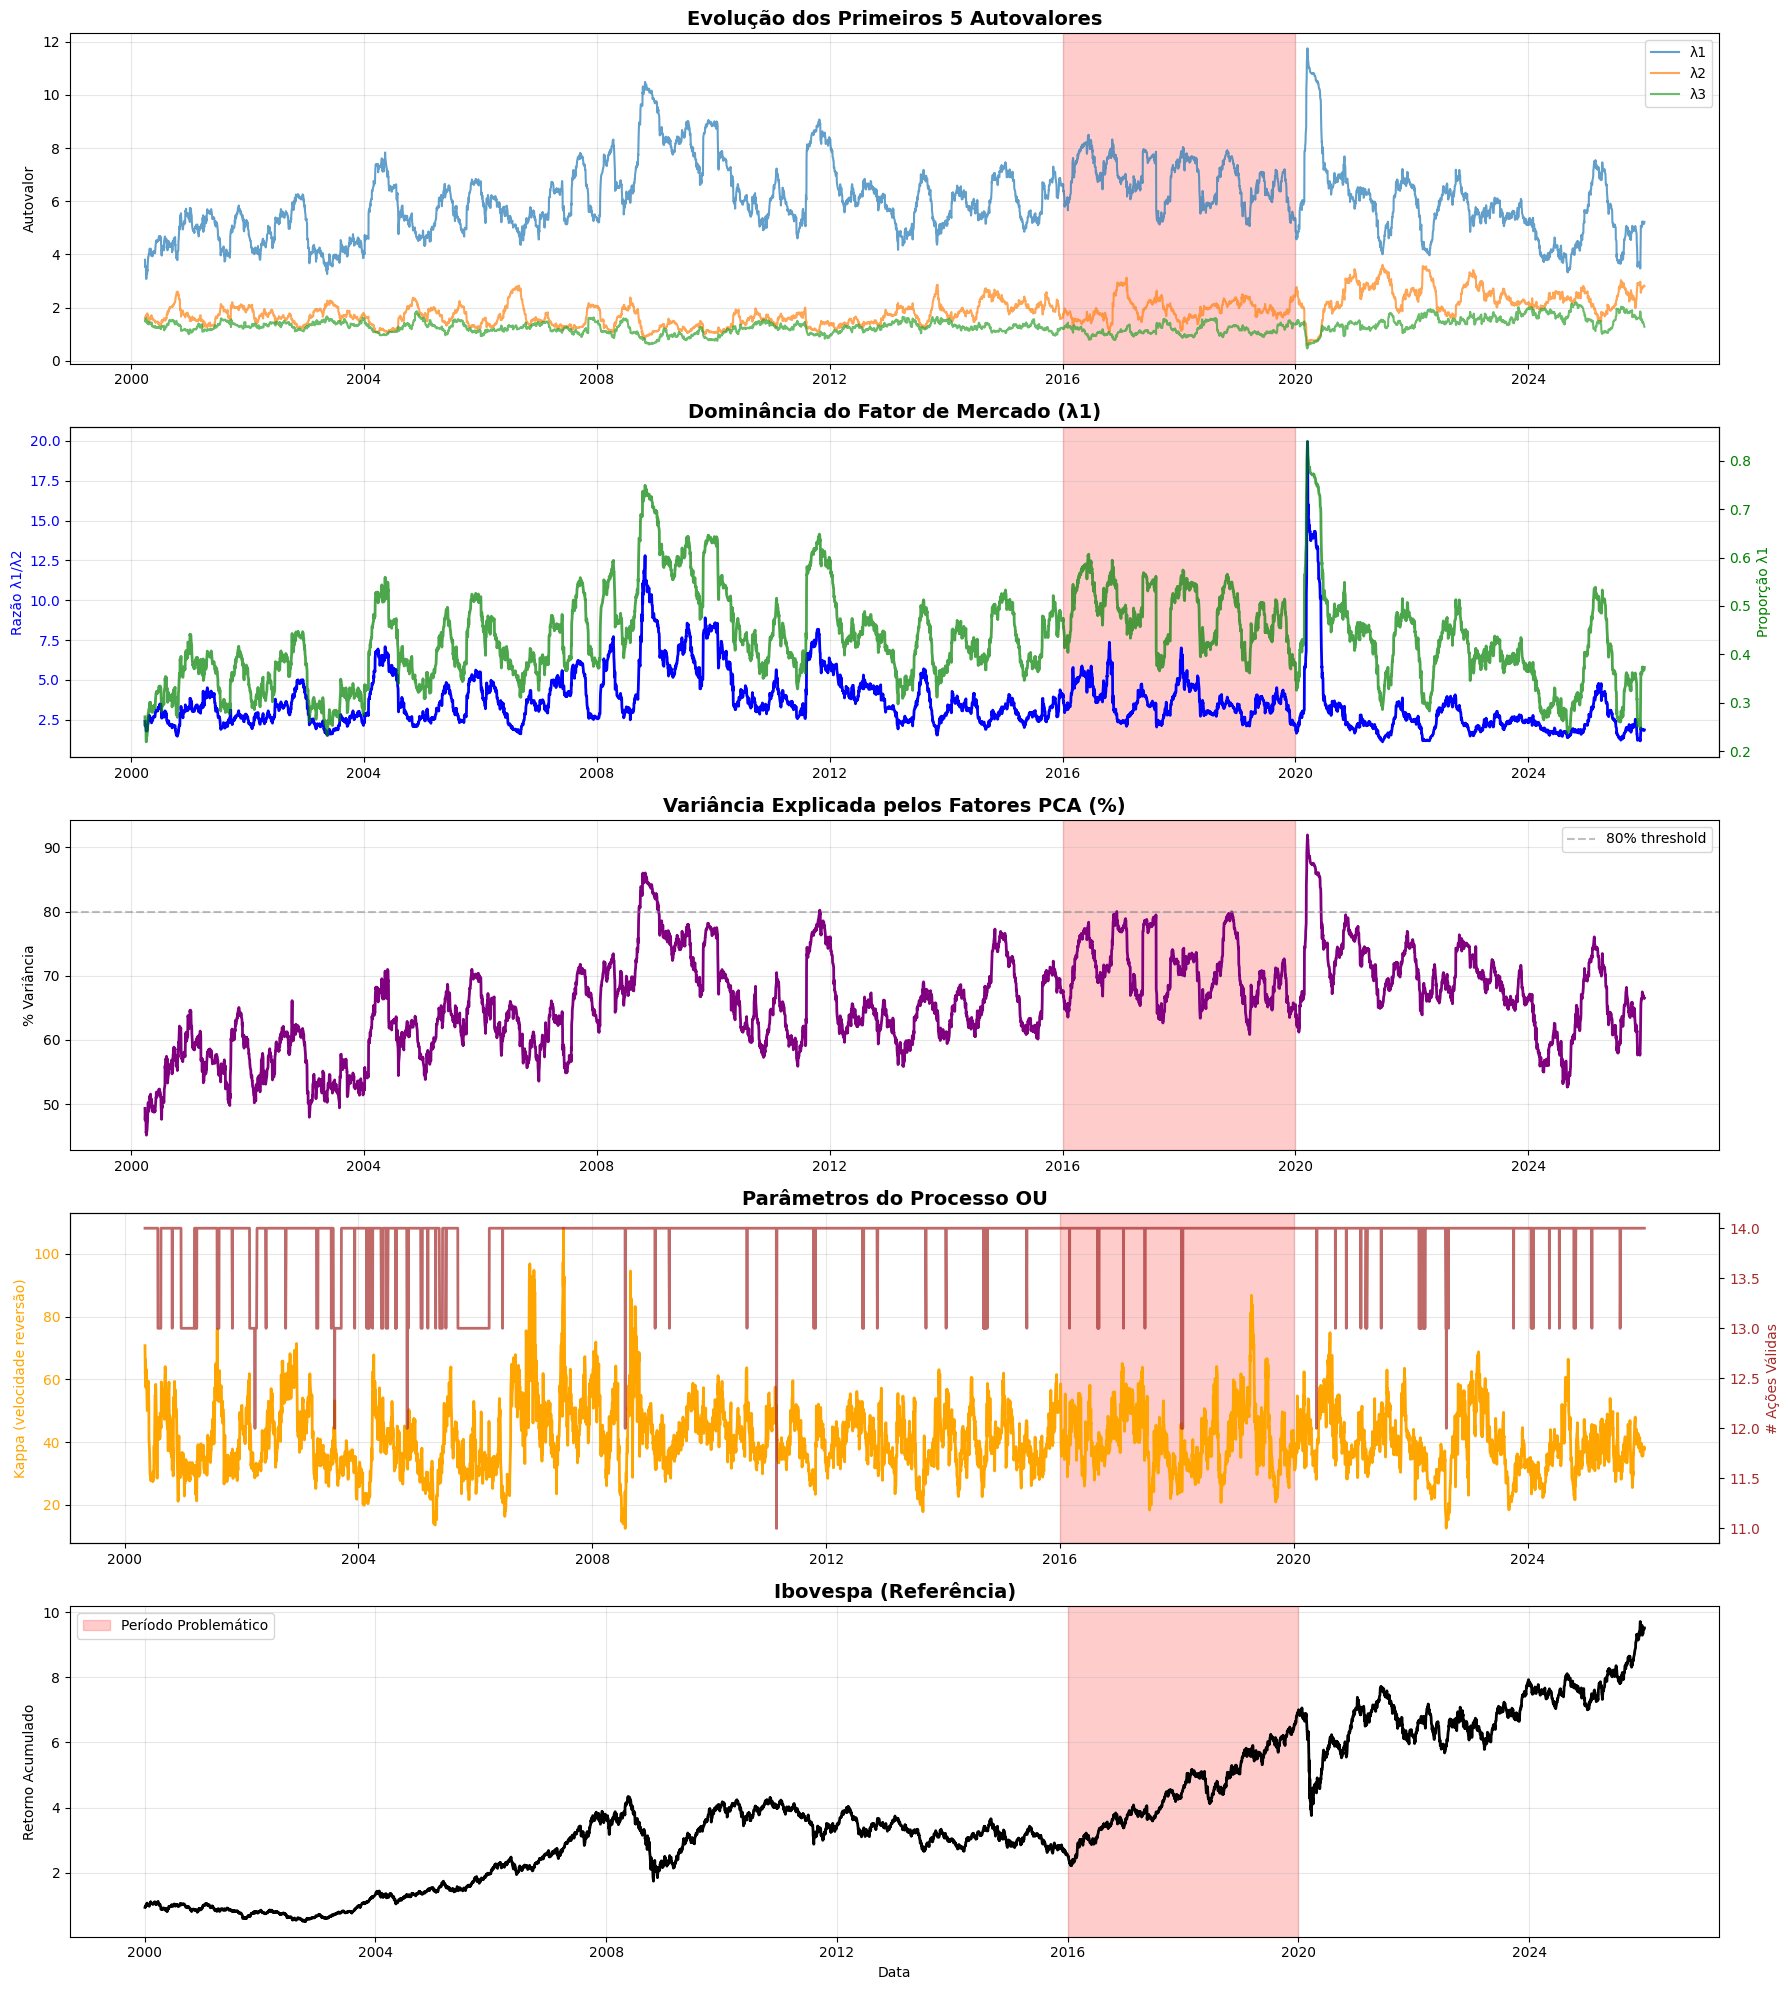

In [25]:
df_eigs, df_var, df_ratios = diagnose_pca_factors(returns_longa, window_pca=60, n_factors=3)
df_ou = diagnose_ou_parameters(returns_longa, results_long['Factor_PCA'], s_win=60, n_factors=3, kappa_min=5.0)
plot_diagnostics(df_eigs, df_var, df_ratios, df_ou, returns_ibov_longa)

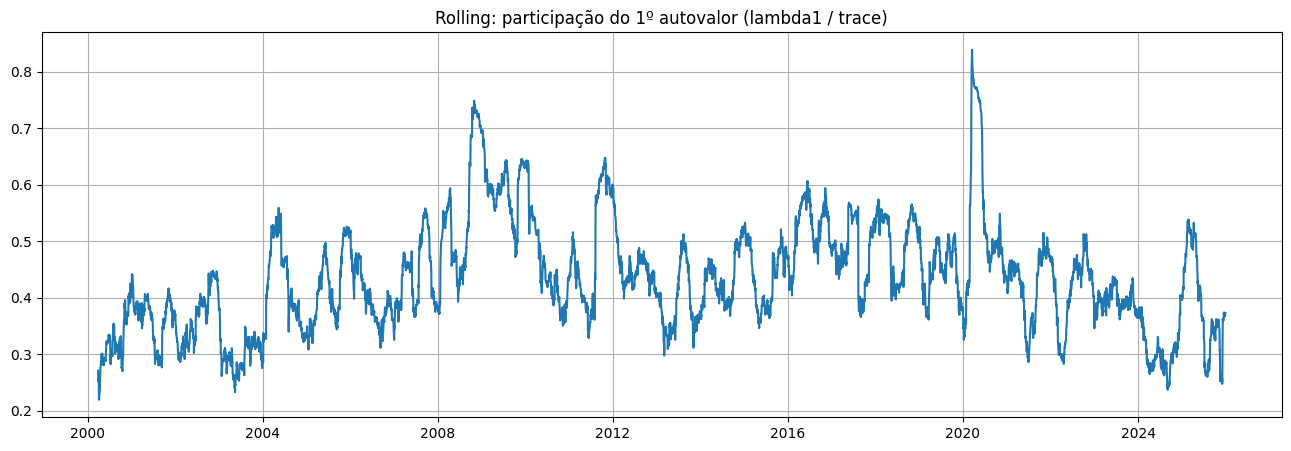

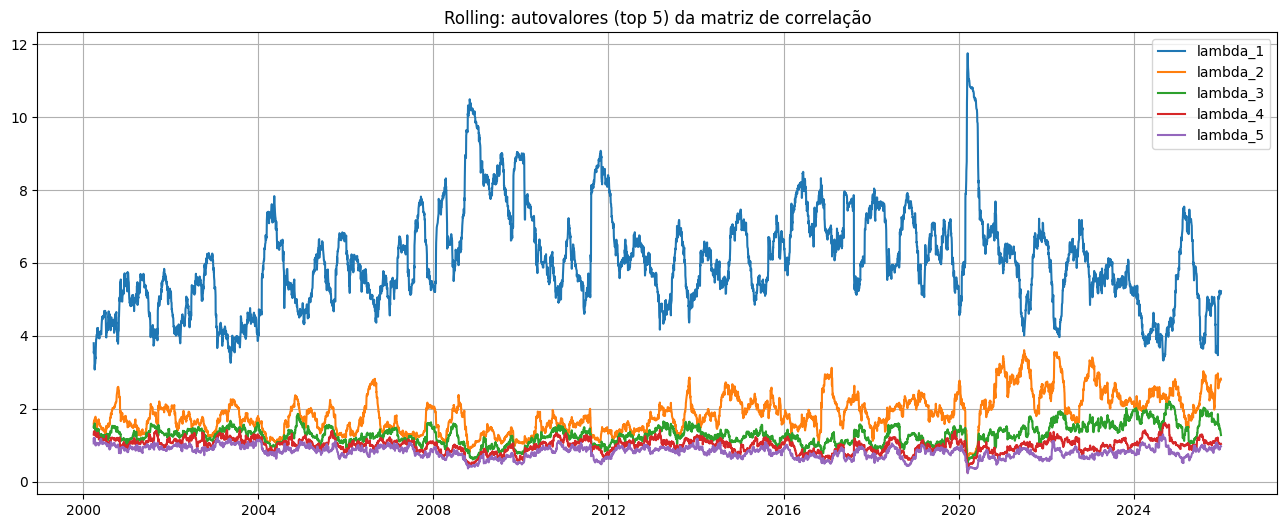

In [26]:
def rolling_pca_spectrum(returns: pd.DataFrame, window: int = 60, max_k: int = 10, min_assets: int = 10):
    dates = returns.index
    K = max_k
    cols_k = [f"lambda_{i+1}" for i in range(K)]

    evals_df = pd.DataFrame(index=dates, columns=cols_k, dtype=float)
    metrics = pd.DataFrame(index=dates, columns=["n_assets", "lambda1_share", "effective_rank", "trace"], dtype=float)

    for i in range(window, len(dates)):
        hist = dates[i-window:i]
        t = dates[i]

        Rw = returns.loc[hist].copy()

        mu = Rw.mean()
        sd = Rw.std(ddof=1).replace(0, np.nan)
        Zw = ((Rw - mu) / sd).dropna(axis=1, how="any")

        n = Zw.shape[1]
        if n < min_assets:
            continue

        C = Zw.corr().values
        w, _ = np.linalg.eigh(C)
        w = np.sort(w)[::-1]

        wK = w[:K]
        # ✅ aqui: usa labels (colunas)
        evals_df.loc[t, cols_k[:len(wK)]] = wK

        tr = float(np.sum(w))
        lambda1_share = float(w[0] / tr) if tr > 0 else np.nan

        p = w / tr if tr > 0 else np.full_like(w, np.nan)
        p = p[p > 0]
        eff_rank = float(np.exp(-np.sum(p * np.log(p)))) if len(p) else np.nan

        metrics.loc[t, "n_assets"] = n
        metrics.loc[t, "lambda1_share"] = lambda1_share
        metrics.loc[t, "effective_rank"] = eff_rank
        metrics.loc[t, "trace"] = tr

    return evals_df.dropna(how="all"), metrics.dropna(how="all")


# uso
evals_df, metrics = rolling_pca_spectrum(returns_longa, window=60, max_k=10, min_assets=10)

plt.figure(figsize=(16,5))
plt.plot(metrics.index, metrics["lambda1_share"])
plt.grid(True)
plt.title("Rolling: participação do 1º autovalor (lambda1 / trace)")
plt.show()

plt.figure(figsize=(16,6))
for c in evals_df.columns[:5]:
    plt.plot(evals_df.index, evals_df[c], label=c)
plt.legend()
plt.grid(True)
plt.title("Rolling: autovalores (top 5) da matriz de correlação")
plt.show()

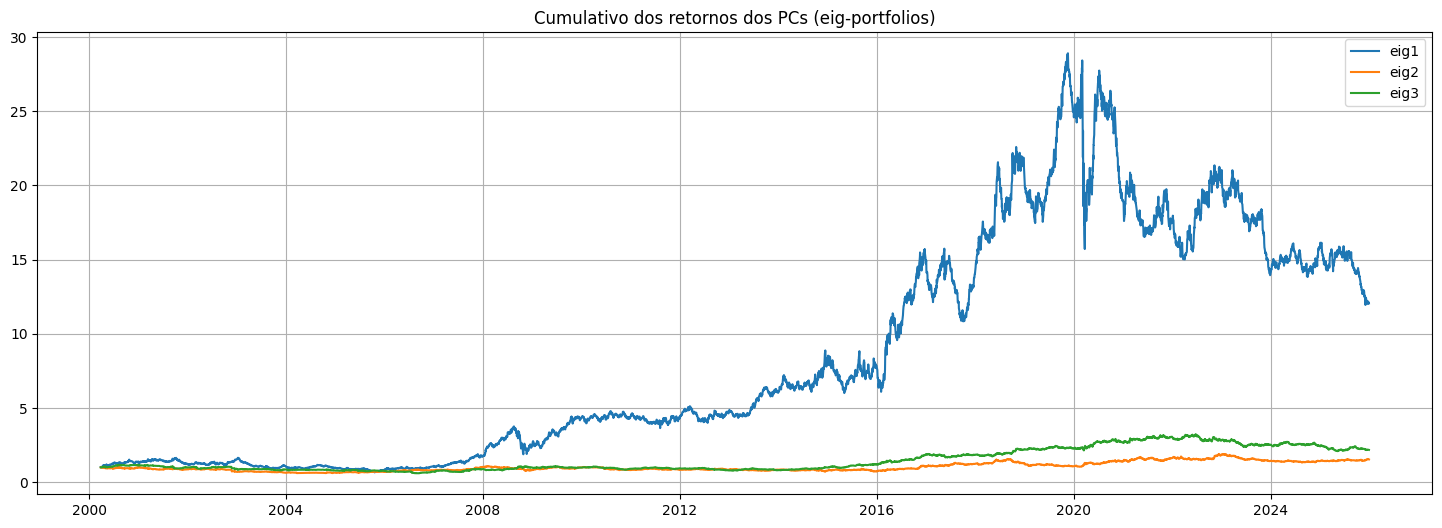

In [27]:
Factor_PCA = results_long_0["Factor_PCA"]
pcs = results_long_0["pcs"]  # ["eig1", ..., "eigK"]

# exemplo: cumulativo dos 3 primeiros PCs
cum = (1 + Factor_PCA[pcs[:3]].fillna(0)).cumprod()

plt.figure(figsize=(18,6))
plt.grid(True)
for c in cum.columns:
    plt.plot(cum.index, cum[c], label=c)
plt.legend()
plt.title("Cumulativo dos retornos dos PCs (eig-portfolios)")
plt.show()

In [28]:
def pnl_attribution(results, returns):
    w = results["w_all"].reindex(returns.index).fillna(0.0)
    w_shift = w.shift(1).fillna(0.0)
    rets = returns.reindex(w.index).fillna(0.0)

    # contribuição diária por ação
    contrib = rets.mul(w_shift)

    # pnl bruto diário (antes de custo)
    pnl_gross = contrib.sum(axis=1)

    # long vs short
    long_contrib = contrib.where(w_shift > 0).sum(axis=1)
    short_contrib = contrib.where(w_shift < 0).sum(axis=1)

    return contrib, pnl_gross, long_contrib, short_contrib


contrib, pnl_gross, long_pnl, short_pnl = pnl_attribution(results_long, returns_longa)

# 1) curva cumulativa long e short
cum_long  = (1 + long_pnl).cumprod()
cum_short = (1 + short_pnl).cumprod()

# 2) quem mais destruiu valor depois de 2015
post = contrib.loc["2015-01-01":]
loss_by_stock = post.sum().sort_values()   # mais negativos no topo
gain_by_stock = post.sum().sort_values(ascending=False)

print("Piores ações pós-2015:")
print(loss_by_stock.head(30))

print("\nMelhores ações pós-2015:")
print(gain_by_stock.head(30))

# 3) checar se o problema é mais do lado short (bem comum)
print("Retorno médio diário pós-2015 long:", long_pnl.loc["2015-01-01":].mean())
print("Retorno médio diário pós-2015 short:", short_pnl.loc["2015-01-01":].mean())

Piores ações pós-2015:
BRAP4.SA   -0.510111
CSNA3.SA   -0.249927
GOAU4.SA   -0.233381
BBDC3.SA   -0.178298
CYRE3.SA   -0.081472
VALE3.SA   -0.076507
ITSA4.SA   -0.042117
USIM5.SA   -0.031377
eig1        0.000000
eig2        0.000000
eig3        0.000000
SBSP3.SA    0.017409
PETR4.SA    0.064830
BBAS3.SA    0.124324
PETR3.SA    0.125484
VIVT3.SA    0.171676
WEGE3.SA    0.173043
dtype: float64

Melhores ações pós-2015:
WEGE3.SA    0.173043
VIVT3.SA    0.171676
PETR3.SA    0.125484
BBAS3.SA    0.124324
PETR4.SA    0.064830
SBSP3.SA    0.017409
eig1        0.000000
eig3        0.000000
eig2        0.000000
USIM5.SA   -0.031377
ITSA4.SA   -0.042117
VALE3.SA   -0.076507
CYRE3.SA   -0.081472
BBDC3.SA   -0.178298
GOAU4.SA   -0.233381
CSNA3.SA   -0.249927
BRAP4.SA   -0.510111
dtype: float64
Retorno médio diário pós-2015 long: 0.00027980483459720784
Retorno médio diário pós-2015 short: -0.0005452137284339688


In [29]:
def trades_from_positions(algo_pos):
    pos = algo_pos.fillna(0.0)
    prev = pos.shift(1).fillna(0.0)
    chg = pos - prev

    trades = []
    for dt in pos.index:
        row = chg.loc[dt]
        changed = row[row != 0]
        if changed.empty:
            continue
        for stock, d in changed.items():
            trades.append({
                "date": dt,
                "stock": stock,
                "delta_pos": float(d),
                "pos_prev": float(prev.loc[dt, stock]),
                "pos_new":  float(pos.loc[dt, stock]),
            })
    return pd.DataFrame(trades).sort_values(["date","stock"])

trades = trades_from_positions(results_long["algo_weights"].apply(np.sign))  # ou use algo_pos se você retornar
print(trades.tail(50))

           date     stock  delta_pos  pos_prev  pos_new
2625 2025-08-07  WEGE3.SA       -1.0       0.0     -1.0
2626 2025-08-08  PETR3.SA        1.0      -1.0      0.0
2627 2025-08-11  WEGE3.SA        1.0      -1.0      0.0
2628 2025-08-14  CSNA3.SA        1.0       0.0      1.0
2629 2025-08-27  PETR4.SA        1.0      -1.0      0.0
2630 2025-08-29  CSNA3.SA       -1.0       1.0      0.0
2631 2025-09-01  VIVT3.SA        1.0       0.0      1.0
2632 2025-09-08  CYRE3.SA       -1.0       1.0      0.0
2633 2025-09-08  SBSP3.SA       -1.0       1.0      0.0
2634 2025-09-16  BBAS3.SA       -1.0       0.0     -1.0
2635 2025-09-18  VALE3.SA       -1.0       0.0     -1.0
2636 2025-09-25  PETR4.SA       -1.0       0.0     -1.0
2637 2025-09-26  PETR3.SA       -1.0       0.0     -1.0
2638 2025-09-30  PETR3.SA        1.0      -1.0      0.0
2639 2025-10-01  PETR4.SA        1.0      -1.0      0.0
2640 2025-10-06  BRAP4.SA       -1.0       0.0     -1.0
2641 2025-10-09  PETR3.SA        1.0       0.0  

In [30]:
ret_net = results_long["ret_net"]
worst = ret_net.nsmallest(10)
best  = ret_net.nlargest(10)

def snapshot_positions(w_all, dt, top=20):
    w = w_all.loc[dt]
    return pd.DataFrame({
        "w": w,
        "side": np.where(w>0,"LONG", np.where(w<0,"SHORT","0"))
    }).loc[w!=0].assign(absw=lambda x: x["w"].abs()).sort_values("absw", ascending=False).head(top)

for dt in worst.index:
    print("\n==== WORST DAY:", dt, "ret=", worst.loc[dt], "====")
    print(snapshot_positions(results_long["w_all"], dt, top=25))


==== WORST DAY: 2020-03-12 00:00:00 ret= -0.12717249347909937 ====
                 w  side      absw
BBDC3.SA  0.142857  LONG  0.142857
BRAP4.SA  0.142857  LONG  0.142857
CYRE3.SA  0.142857  LONG  0.142857
ITSA4.SA  0.142857  LONG  0.142857
PETR3.SA  0.142857  LONG  0.142857
PETR4.SA  0.142857  LONG  0.142857
VALE3.SA  0.142857  LONG  0.142857

==== WORST DAY: 2020-03-16 00:00:00 ret= -0.11910014780240646 ====
                 w   side      absw
BBDC3.SA  0.146352   LONG  0.146352
BRAP4.SA  0.146352   LONG  0.146352
CYRE3.SA  0.146352   LONG  0.146352
ITSA4.SA  0.146352   LONG  0.146352
PETR3.SA  0.146352   LONG  0.146352
PETR4.SA  0.146352   LONG  0.146352
eig1     -0.077487  SHORT  0.077487
eig2      0.031760   LONG  0.031760
eig3     -0.012639  SHORT  0.012639

==== WORST DAY: 2020-03-18 00:00:00 ret= -0.08858136638197214 ====
                 w   side      absw
BBDC3.SA  0.146558   LONG  0.146558
BRAP4.SA  0.146558   LONG  0.146558
CYRE3.SA  0.146558   LONG  0.146558
ITSA4.SA  0.

In [31]:
W = results_long["w_all"]
n_nonzero = (W.abs() > 1e-12).sum(axis=1)
print(n_nonzero.describe())

print("Frac dias com <=2 nomes:", (n_nonzero <= 2).mean())
print("Frac dias com 1 nome:", (n_nonzero == 1).mean())

print("Pré-2015 1 nome:", (n_nonzero.loc[:"2014-12-31"]==1).mean())
print("Pós-2015 1 nome:", (n_nonzero.loc["2015-01-01":]==2).mean())

count    6405.000000
mean        7.910226
std         2.530247
min         0.000000
25%         6.000000
50%         8.000000
75%        10.000000
max        15.000000
dtype: float64
Frac dias com <=2 nomes: 0.023575331772053083
Frac dias com 1 nome: 0.006401249024199844
Pré-2015 1 nome: 0.010087241003271538
Pós-2015 1 nome: 0.006941907197661673


In [32]:
s = results_long["s_scores"]
pos = np.sign(results_long["algo_weights"])  # proxy, mas ok

# eventos de abertura: de 0 -> -1 e 0 -> +1
pos_prev = pos.shift(1).fillna(0.0)
open_short = (pos_prev == 0) & (pos == -1)
open_long  = (pos_prev == 0) & (pos == +1)

h = 5
fwd = (1 + returns_longa).rolling(h).apply(np.prod, raw=True).shift(-h) - 1

short_fwd = fwd.where(open_short).stack().dropna()
long_fwd  = fwd.where(open_long ).stack().dropna()

print("FWD(5d) médio quando ABRE SHORT:", short_fwd.mean())
print("FWD(5d) médio quando ABRE LONG :", long_fwd.mean())

print("Pré-2015 SHORT open:", short_fwd.loc[short_fwd.index.get_level_values(0) <= "2014-12-31"].mean())
print("Pós-2015 SHORT open:", short_fwd.loc[short_fwd.index.get_level_values(0) >= "2015-01-01"].mean())

FWD(5d) médio quando ABRE SHORT: 0.004087642964443748
FWD(5d) médio quando ABRE LONG : 0.000989000734945239
Pré-2015 SHORT open: 0.002126292747931756
Pós-2015 SHORT open: 0.006567587475491112


In [33]:
s_trade_short = s.where(open_short).stack().dropna()
s_trade_long  = s.where(open_long ).stack().dropna()

print("s-score médio em aberturas short:", s_trade_short.mean())
print("s-score médio em aberturas long :", s_trade_long.mean())

s-score médio em aberturas short: 1.4342180286789237
s-score médio em aberturas long : -1.4292924316904663


In [34]:
s_scores = results_long["s_scores"]
algo_w = results_long["algo_weights"]
w_all  = results_long["w_all"]
turn   = results_long["turnover"]

# quantos s-scores válidos por dia
n_scores = s_scores.notna().sum(axis=1)

# quantos longs/shorts por dia (a partir de weights)
n_longs  = (algo_w > 0).sum(axis=1)
n_shorts = (algo_w < 0).sum(axis=1)

# gross exposure (antes/depois do hedge e normalização)
gross_stocks = algo_w.abs().sum(axis=1)
gross_all    = w_all.abs().sum(axis=1)

dbg = pd.DataFrame({
    "n_scores": n_scores,
    "n_longs": n_longs,
    "n_shorts": n_shorts,
    "gross_stocks": gross_stocks,
    "gross_all": gross_all,
    "turnover": turn.reindex(gross_all.index),
})

# agregue por ano pra ver queda estrutural
yearly = dbg.groupby(dbg.index.year).mean()
print(yearly.loc[2005:2025])

       n_scores   n_longs  n_shorts  gross_stocks  gross_all  turnover
Date                                                                  
2005   9.152610  2.610442  1.803213      1.714859   1.000000  0.200089
2006  11.403101  1.941860  2.131783      1.608527   0.949612  0.209681
2007  11.951020  1.861224  3.587755      1.808163   1.000000  0.231265
2008  10.807229  1.795181  1.293173      1.654618   0.987952  0.191832
2009  11.955645  2.822581  1.814516      1.766129   0.983871  0.224922
2010  12.542510  2.145749  2.781377      1.838057   0.991903  0.234538
2011  10.730924  3.028112  2.425703      1.847390   0.987952  0.189799
2012  10.212245  3.567347  3.428571      1.967347   1.000000  0.209199
2013   9.616935  2.479839  3.661290      1.915323   1.000000  0.176390
2014  10.846774  1.983871  2.217742      1.741935   1.000000  0.213831
2015  10.613821  2.617886  2.191057      1.857724   0.987805  0.249606
2016   9.610442  2.313253  2.654618      1.907631   0.991968  0.186969
2017  

In [35]:
w_all = results_long["w_all"].copy()
rets_all = pd.concat([returns_longa, results_long["Factor_PCA"]], axis=1)

common_cols = w_all.columns.intersection(rets_all.columns)
w = w_all[common_cols].reindex(rets_all.index).fillna(0.0)
r = rets_all[common_cols].reindex(w.index)

w_shift = w.shift(1).fillna(0.0)

stock_cols = returns_longa.columns.intersection(common_cols)
pc_cols    = pd.Index(results_long["pcs"]).intersection(common_cols)

ret_stock = (r[stock_cols] * w_shift[stock_cols]).sum(axis=1)
ret_hedge = (r[pc_cols]    * w_shift[pc_cols]).sum(axis=1)

turnover = (w - w.shift(1)).abs().sum(axis=1).fillna(0.0)
cost = 0.0005 * turnover

ret_net_rebuild = ret_stock + ret_hedge - cost

decomp = pd.DataFrame({
    "ret_stock": ret_stock,
    "ret_hedge": ret_hedge,
    "cost": cost,
    "ret_net": results_long["ret_net"].reindex(ret_stock.index),
    "diff": (results_long["ret_net"].reindex(ret_stock.index) - ret_net_rebuild),
})

print(decomp[["diff"]].abs().max())  # deve ser ~0; sanity check
print(decomp.groupby(decomp.index.year)[["ret_stock","ret_hedge","cost"]].mean().loc[2005:2025])

diff    1.387779e-17
dtype: float64
      ret_stock  ret_hedge      cost
Date                                
2005   0.000666  -0.000119  0.000100
2006   0.001552   0.000077  0.000105
2007   0.000374  -0.000202  0.000116
2008   0.000786  -0.000076  0.000096
2009   0.000395   0.000017  0.000112
2010   0.000436   0.000083  0.000117
2011   0.000049   0.000079  0.000095
2012  -0.000101   0.000059  0.000105
2013  -0.001036  -0.000062  0.000088
2014  -0.000545   0.000036  0.000107
2015  -0.000787   0.000019  0.000125
2016  -0.000311   0.000189  0.000093
2017  -0.000084  -0.000035  0.000085
2018   0.000085   0.000001  0.000095
2019  -0.000953   0.000059  0.000097
2020  -0.000431   0.000543  0.000104
2021  -0.000179   0.000100  0.000105
2022   0.000248  -0.000048  0.000093
2023  -0.000723   0.000041  0.000091
2024   0.000254  -0.000079  0.000092
2025  -0.000056  -0.000046  0.000096


In [36]:
dd = (1 + results_long["ret_net"]).cumprod()
peak = dd.cummax()
drawdown = dd/peak - 1

worst = drawdown.nsmallest(20)
print(worst)

# Para esses dias, olhe decomposição
print(decomp.loc[worst.index, ["ret_stock","ret_hedge","cost","ret_net"]])

Date
2025-06-09   -0.805223
2025-07-10   -0.804784
2025-07-09   -0.804334
2025-07-11   -0.804311
2025-07-30   -0.804221
2025-07-21   -0.804147
2025-07-14   -0.804083
2025-06-10   -0.803628
2025-07-07   -0.803609
2025-07-18   -0.803492
2025-07-16   -0.803455
2025-07-22   -0.803410
2025-07-08   -0.803156
2025-07-29   -0.803064
2025-07-03   -0.803044
2025-07-31   -0.802909
2025-07-28   -0.802839
2025-07-24   -0.802809
2025-06-06   -0.802798
2025-07-04   -0.802681
dtype: float64
            ret_stock  ret_hedge          cost   ret_net
Date                                                    
2025-06-09  -0.011813  -0.000368  1.187269e-04 -0.012300
2025-07-10  -0.001633  -0.000486  1.806745e-04 -0.002299
2025-07-09  -0.006655   0.000688  2.024507e-05 -0.005987
2025-07-11   0.002408   0.000017  1.897694e-06  0.002422
2025-07-30  -0.004380  -0.001266  2.275953e-04 -0.005874
2025-07-21  -0.002644  -0.000650  3.821218e-05 -0.003332
2025-07-14   0.000783   0.000596  2.115170e-04  0.001168
2025-06

In [ ]:
#pip install quantstats
import quantstats as qs

#qs.reports.html(cum_algo, output="relatorio.html", title="Relatório da Estratégia")


## Otimizador

In [ ]:
# --------------------------
# Métrica
# --------------------------
def sharpe_ann(r: pd.Series, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 60:
        return np.nan
    vol = r.std(ddof=1)
    if vol == 0 or not np.isfinite(vol):
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / vol)


def score_strategy(ret_net: pd.Series, trading_days: int = 252) -> float:
    r = ret_net.dropna()
    if len(r) < 60:
        return -np.inf
    sh = sharpe_ann(r, trading_days=trading_days)
    if np.isnan(sh):
        return -np.inf
    return sh

def splits(
    index: pd.Index,
    *,
    n_folds: int = 4,
    window_size: int = 252 * 2,          # tamanho da janela (ex.: 2 anos)
    step_size: int | None = None,        # avanço entre janelas (ex.: 1 ano)
) -> list[tuple[int, int]]:
    """
    Retorna lista de (start, end) como posições inteiras.
    """
    n = len(index)
    if n_folds <= 0 or window_size <= 0:
        return []

    if step_size is None:
        step_size = window_size // 2  # default razoável: meia janela
        if step_size <= 0:
            step_size = 1

    split: list[tuple[int, int]] = []
    start = 0

    for _ in range(n_folds):
        end = start + window_size
        if end > n:
            break
        split.append((start, end))
        start += step_size

    return split


# --------------------------
# Avaliação por folds
# --------------------------
def eval_params(
    returns: pd.DataFrame,
    returns_bench: pd.Series | pd.DataFrame,
    params: dict,
    trial: optuna.Trial | None = None,
    *,
    n_folds: int = 4,
    window_size: int = 252 * 2,
    step_size: int | None = None,
    min_points: int = 60,   # mínimo para considerar fold válido
    apply_purge_in_score: bool = True,
) -> float:
    """
    - Roda o backtest em cada janela (fold) e faz score na própria janela.
    """
    # --------------------------
    # alinhamento global
    # --------------------------
    if isinstance(returns_bench, pd.Series):
        common = returns.index.intersection(returns_bench.index)
        returns = returns.loc[common]
        returns_bench = returns_bench.loc[common]
    else:
        common = returns.index.intersection(returns_bench.index)
        returns = returns.loc[common]
        returns_bench = returns_bench.loc[common]

    if len(returns) < min_points:
        return -np.inf

    # purge depende das janelas do método
    s_win = int(params["s_win"])
    ma_window = int(params["ma_window"])
    purge = max(s_win, ma_window) + 5  

    # gerar folds 
    folds = splits(
        returns.index,
        n_folds=n_folds,
        window_size=window_size,
        step_size=step_size,
    )
    if not folds:
        return -np.inf

    fold_scores: list[float] = []

    for k, (start, end) in enumerate(folds):
        sub_returns = returns.iloc[start:end]
        sub_bench = returns_bench.iloc[start:end]

        # alinhamento dentro do fold
        if isinstance(sub_bench, pd.Series):
            aligned = sub_returns.join(sub_bench.rename("bench"), how="inner")
            sub_returns = aligned[sub_returns.columns]
            sub_bench = aligned["bench"]
        else:
            aligned = sub_returns.join(sub_bench, how="inner")
            sub_returns = aligned[sub_returns.columns]
            sub_bench = aligned[sub_bench.columns]

        if len(aligned) < max(min_points, purge + 1):
            return -np.inf

        # roda o backtest no fold (somente treino)
        try:
            res = pca_portfolio_hedge(
                returns=sub_returns,
                returns_bench=sub_bench,
                benchmark=params.get("benchmark", "BENCH"),
                num_pc=int(params["num_pc"]),
                s_win=s_win,
                sbo=float(params["sbo"]),
                sso=float(params["sso"]),
                sbc=float(params["sbc"]),
                ssc=float(params["ssc"]),
                eps_cost=float(params["eps_cost"]),
                rebalanceamento_dias=int(params["rebalanceamento_dias"]),
                kappa_min=float(params["kappa_min"]),
                plot=False,
                use_drift=bool(params["use_drift"]),
                ma_window=ma_window,
                verbose=False,
            )
        except Exception:
            return -np.inf

        # score no próprio treino do fold
        ret_net_fold = res["ret_net"].reindex(aligned.index).dropna()
        if apply_purge_in_score and purge > 0:
            ret_net_fold = ret_net_fold.iloc[purge:]  # queima começo do fold na pontuação

        if len(ret_net_fold) < min_points:
            return -np.inf

        fold_score = score_strategy(ret_net_fold)
        fold_scores.append(float(fold_score))

        # pruning com Optuna
        if trial is not None:
            trial.report(float(np.mean(fold_scores)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


# --------------------------
# Optuna
# --------------------------
def optimize_optuna(
    returns: pd.DataFrame,
    returns_bench: pd.Series | pd.DataFrame,
    *,
    n_trials: int = 60,
    n_folds: int = 4,
    train_size: int = 252 * 2,
    test_size: int = 252,
    step_size: int | None = None,
    seed: int = 42,
    study_name: str = "pca_hedge_long_v1",
    storage: str = "sqlite:///optuna_br.db",
):
    """
    Otimiza parâmetros maximizando Sharpe médio OOS em rolling walk-forward.
    """

    def objective(trial: optuna.Trial) -> float:
        now = time.strftime("%H:%M:%S")
        pid = os.getpid()
        tname = threading.current_thread().name
        print(f"[{now}] START trial={trial.number} pid={pid} thread={tname}")

        # --------------------------
        # Hiperparâmetros
        # --------------------------
        s_win = trial.suggest_int("s_win", 60, 250, step=5)
        ma_window = trial.suggest_int("ma_window", 20, s_win - 2, step=2)

        sbo = trial.suggest_float("sbo", 0.8, 2.5)
        sso = trial.suggest_float("sso", 0.8, 2.5)

        sbc = trial.suggest_float("sbc", 0.1, sso - 0.05)  # close short < open short
        ssc = trial.suggest_float("ssc", 0.1, sbo - 0.05)  # close long  < open long

        kappa_min = trial.suggest_float("kappa_min", 1.0, 20.0)
        num_pc = trial.suggest_int("num_pc", 1, 12)
        rebalanceamento_dias = trial.suggest_int("rebalanceamento_dias", 1, 30)

        params = dict(
            benchmark="IBOV",
            num_pc=num_pc,
            s_win=s_win,
            ma_window=ma_window,
            sbo=sbo,
            sso=sso,
            sbc=sbc,
            ssc=ssc,
            eps_cost=0.0005,
            rebalanceamento_dias=rebalanceamento_dias,
            kappa_min=kappa_min,
            plot=False,
            use_drift=True,
            verbose=False,
        )

        return eval_params(
            returns,
            returns_bench,
            params,
            trial=trial,
            n_folds=n_folds,
            train_size=train_size,
            test_size=test_size,
            step_size=step_size,
        )

    sampler = optuna.samplers.TPESampler(seed=seed)
    pruner = optuna.pruners.HyperbandPruner(
        min_resource=1,
        max_resource=n_folds,
        reduction_factor=3,
    )

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner,
        study_name=study_name,
        storage=storage,
        load_if_exists=True,
    )

    study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=True)
    return study

In [12]:
returns_train = returns_longa.loc["2000-01-01":"2006-12-31"]  # 7 anos
bench_train   = returns_ibov_longa.loc["2000-01-01":"2006-12-31"]

returns_opt = returns_longa.loc["2007-01-01":"2025-12-31"]
bench_opt   = returns_ibov_longa.loc["2007-01-01":"2025-12-31"]

In [13]:
study = optimize_optuna(
    returns_train,
    bench_train,
    n_trials=80,
    n_folds=4,
    train_size=252*2,
    test_size=252,
    step_size=252,
    study_name="optuna_for_br"   
)

best = study.best_params
print(best)

[I 2026-02-23 10:13:17,985] A new study created in RDB with name: optuna_for_br
  0%|          | 0/80 [00:00<?, ?it/s]

[10:13:18] START trial=0 pid=16232 thread=MainThread


Best trial: 0. Best value: -0.354706:   1%|▏         | 1/80 [03:09<4:08:56, 189.08s/it]

[I 2026-02-23 10:16:27,053] Trial 0 finished with value: -0.35470576703538614 and parameters: {'s_win': 130, 'ma_window': 116, 'sbo': 2.044389701079389, 'sso': 1.8177194231349623, 'sbc': 0.3601953170369613, 'ssc': 0.39551441274972154, 'kappa_min': 2.1035886311957896, 'num_pc': 11, 'rebalanceamento_dias': 19}. Best is trial 0 with value: -0.35470576703538614.
[10:16:27] START trial=1 pid=16232 thread=MainThread


Best trial: 0. Best value: -0.354706:   2%|▎         | 2/80 [05:35<3:33:12, 164.01s/it]

...

[I 2026-02-23 13:53:13,373] Trial 77 pruned. 
[13:53:13] START trial=78 pid=16232 thread=MainThread


Best trial: 49. Best value: 2.82203:  99%|█████████▉| 79/80 [3:42:49<02:40, 160.20s/it]

[I 2026-02-23 13:56:07,059] Trial 78 finished with value: 1.944976610284339 and parameters: {'s_win': 175, 'ma_window': 56, 'sbo': 1.0757345407101373, 'sso': 2.313094119929888, 'sbc': 0.6719331523057664, 'ssc': 0.3508455249964567, 'kappa_min': 17.09338059807793, 'num_pc': 2, 'rebalanceamento_dias': 4}. Best is trial 49 with value: 2.822026111670836.
[13:56:07] START trial=79 pid=16232 thread=MainThread


Best trial: 49. Best value: 2.82203: 100%|██████████| 80/80 [3:45:45<00:00, 169.31s/it]

[I 2026-02-23 13:59:03,090] Trial 79 finished with value: 2.113422752791413 and parameters: {'s_win': 145, 'ma_window': 58, 'sbo': 0.8528868041021498, 'sso': 2.2161025338638307, 'sbc': 0.43282361723609136, 'ssc': 0.5125420160142528, 'kappa_min': 14.351947660800692, 'num_pc': 3, 'rebalanceamento_dias': 3}. Best is trial 49 with value: 2.822026111670836.
{'s_win': 170, 'ma_window': 100, 'sbo': 0.8481848144933328, 'sso': 2.3984900019951185, 'sbc': 0.8648766210519527, 'ssc': 0.4986333073008427, 'kappa_min': 13.394478080608586, 'num_pc': 6, 'rebalanceamento_dias': 4}


Tempo : 2007-09-06 00:00:00
Tempo : 2007-09-10 00:00:00
Tempo : 2007-09-11 00:00:00
Tempo : 2007-09-12 00:00:00
Tempo : 2007-09-13 00:00:00
Tempo : 2007-09-14 00:00:00
Tempo : 2007-09-17 00:00:00
Tempo : 2007-09-18 00:00:00
Tempo : 2007-09-19 00:00:00
Tempo : 2007-09-20 00:00:00
Tempo : 2007-09-21 00:00:00
Tempo : 2007-09-24 00:00:00
Tempo : 2007-09-25 00:00:00
Tempo : 2007-09-26 00:00:00
Tempo : 2007-09-27 00:00:00
Tempo : 2007-09-28 00:00:00
Tempo : 2007-10-01 00:00:00
Tempo : 2007-10-02 00:00:00
Tempo : 2007-10-03 00:00:00
Tempo : 2007-10-04 00:00:00
Tempo : 2007-10-05 00:00:00
Tempo : 2007-10-08 00:00:00
Tempo : 2007-10-09 00:00:00
Tempo : 2007-10-10 00:00:00
Tempo : 2007-10-11 00:00:00
Tempo : 2007-10-15 00:00:00
Tempo : 2007-10-16 00:00:00
Tempo : 2007-10-17 00:00:00
Tempo : 2007-10-18 00:00:00
Tempo : 2007-10-19 00:00:00
Tempo : 2007-10-22 00:00:00
Tempo : 2007-10-23 00:00:00
Tempo : 2007-10-24 00:00:00
Tempo : 2007-10-25 00:00:00
Tempo : 2007-10-26 00:00:00
Tempo : 2007-10-29 0

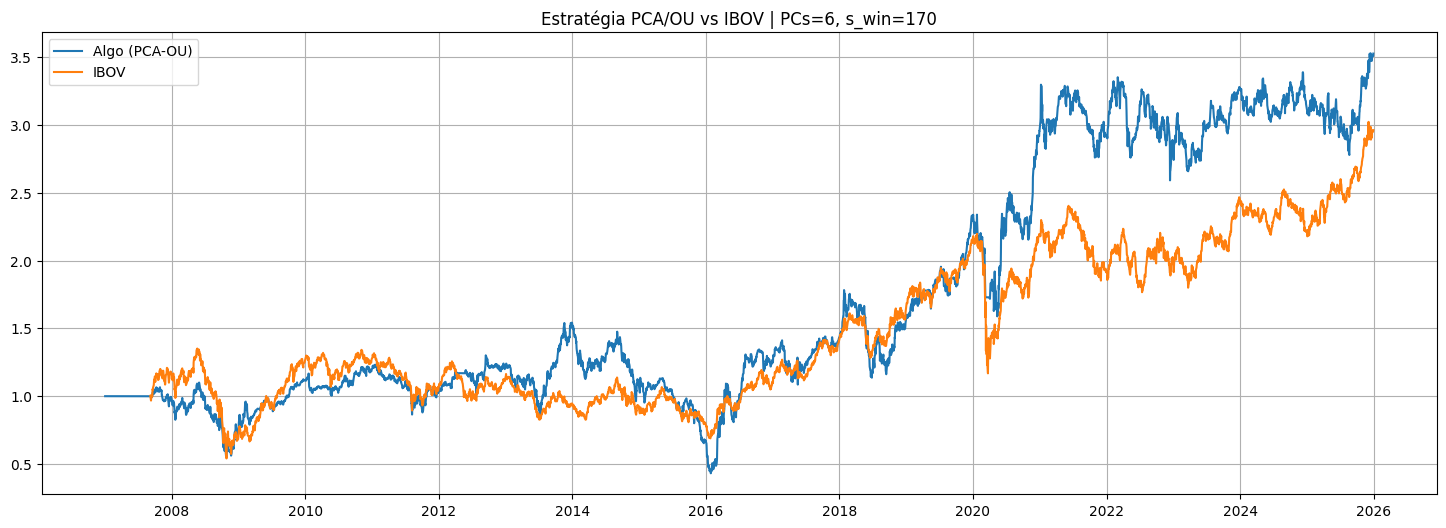

In [ ]:
res_oos = pca_portfolio_hedge(
    returns=returns_opt,
    returns_bench=bench_opt,
    benchmark="IBOV",
    num_pc=int(best["num_pc"]),
    s_win=int(best["s_win"]),
    ma_window=int(best["ma_window"]),
    sbo=float(best["sbo"]),
    sso=float(best["sso"]),
    sbc=float(best["sbc"]),
    ssc=float(best["ssc"]),
    eps_cost=0.0005,
    rebalanceamento_dias=int(best["rebalanceamento_dias"]),
    kappa_min=float(best["kappa_min"]),
    plot=True,
    use_drift=True,
    verbose=True
)

# Colocar plt.title("Walk-Forward Optimized Strategy vs IBOV (2007-2025)", fontsize=16, fontweight='bold')


In [16]:
# =============================================================================
# 3. ESTATÍSTICAS BÁSICAS
# =============================================================================

ret_res = res_oos['ret_net']
stats_res = stats_from_returns(ret_res)

print("\n" + "="*70)
print("PERFORMANCE DA ESTRATÉGIA (1999-2025)")
print("="*70)
for k, v in stats_res.items():
    print(f"  {k:10s}: {v:>10.4f} ({v*100:>7.2f}%)")
print("="*70 + "\n")


PERFORMANCE DA ESTRATÉGIA (1999-2025)
  CAGR      :     0.0697 (   6.97%)
  Vol       :     0.2766 (  27.66%)
  Sharpe    :     0.2519 (  25.19%)
  MaxDD     :    -0.7200 ( -72.00%)



### Otimização usando walk-forward

In [23]:
# --------------------------
# MÉTRICAS
# --------------------------
def sharpe_ann(r: pd.Series, trading_days: int = 252) -> float:
    r = r.dropna()
    if len(r) < 60:
        return np.nan
    vol = r.std(ddof=1)
    if vol == 0 or not np.isfinite(vol):
        return np.nan
    return float(np.sqrt(trading_days) * r.mean() / vol)

def score_strategy(ret_net: pd.Series, trading_days: int = 252) -> float:
    r = ret_net.dropna()
    if len(r) < 60:
        return -np.inf
    sh = sharpe_ann(r, trading_days=trading_days)
    if np.isnan(sh):
        return -np.inf
    return sh

def splits(index: pd.Index, *, n_folds: int = 3, window_size: int = 252*2, step_size: int | None = 252):
    n = len(index)
    if step_size is None:
        step_size = window_size // 2
        step_size = max(step_size, 1)

    out = []
    start = 0
    for _ in range(n_folds):
        end = start + window_size
        if end > n:
            break
        out.append((start, end))
        start += step_size
    return out

def eval_params_train_cv(
    returns_train: pd.DataFrame,
    bench_train: pd.Series | pd.DataFrame,
    params: dict,
    trial: optuna.Trial | None = None,
    *,
    n_folds: int = 3,
    window_size: int = 252*2,
    step_size: int | None = 252,
    min_points: int = 60,
) -> float:
    # alinhamento local (treino)
    common = returns_train.index.intersection(bench_train.index)
    returns_train = returns_train.loc[common]
    bench_train   = bench_train.loc[common]

    if len(returns_train) < window_size + min_points:
        return -np.inf

    fold_scores = []
    for k, (st, en) in enumerate(splits(returns_train.index, n_folds=n_folds, window_size=window_size, step_size=step_size)):
        R = returns_train.iloc[st:en]
        B = bench_train.iloc[st:en]

        try:
            res = pca_portfolio_hedge(
                returns=R,
                returns_bench=B,
                benchmark=params.get("benchmark", "BENCH"),
                num_pc=int(params["num_pc"]),
                s_win=int(params["s_win"]),
                sbo=float(params["sbo"]),
                sso=float(params["sso"]),
                sbc=float(params["sbc"]),
                ssc=float(params["ssc"]),
                eps_cost=float(params["eps_cost"]),
                rebalanceamento_dias=int(params["rebalanceamento_dias"]),
                kappa_min=float(params["kappa_min"]),
                plot=False,
                use_drift=bool(params["use_drift"]),
                ma_window=int(params["ma_window"]),
                verbose=False,
            )
        except Exception:
            return -np.inf

        ret_fold = res["ret_net"].reindex(R.index).dropna()
        if len(ret_fold) < min_points:
            return -np.inf

        fold_scores.append(score_strategy(ret_fold))

        if trial is not None:
            trial.report(float(np.mean(fold_scores)), step=k)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return float(np.mean(fold_scores)) if fold_scores else -np.inf

In [24]:
def optimize_then_trade_yearly_with_gap(
    returns: pd.DataFrame,
    bench: pd.Series | pd.DataFrame,
    *,
    train_years: int = 4,
    gap_years: int = 1,
    start_test_year: int = 2005,
    end_test_year: int = 2025,
    n_trials: int = 60,
    n_folds: int = 3,
    cv_window_size: int = 252*2,
    cv_step_size: int = 252,
    seed: int = 42,
    storage: str = "sqlite:///optuna_yearly.db",
    study_prefix: str = "wfo",
    params_ckpt_path: str = "params_by_year.csv",
    rets_ckpt_path: str = "ret_oos.parquet",
):
    # alinhamento global
    common = returns.index.intersection(bench.index)
    returns = returns.loc[common]
    bench   = bench.loc[common]

    # --------- resume: carregar checkpoints se existirem
    if os.path.exists(params_ckpt_path):
        params_table = pd.read_csv(params_ckpt_path)
    else:
        params_table = pd.DataFrame()

    if os.path.exists(rets_ckpt_path):
        ret_oos_all = pd.read_parquet(rets_ckpt_path)["ret_oos"]
        ret_oos_all.index = pd.to_datetime(ret_oos_all.index)
        ret_oos_all = ret_oos_all.sort_index()
    else:
        ret_oos_all = pd.Series(dtype=float, name="ret_oos")

    done_years = set(params_table["year_test"].tolist()) if not params_table.empty else set()

    def objective_factory(R_train, B_train):
        def objective(trial: optuna.Trial) -> float:
            s_win = trial.suggest_int("s_win", 60, 250, step=5)
            ma_window = trial.suggest_int("ma_window", 20, s_win - 2, step=2)

            sbo = trial.suggest_float("sbo", 0.8, 2.5)
            sso = trial.suggest_float("sso", 0.8, 2.5)
            sbc = trial.suggest_float("sbc", 0.1, sso - 0.05)
            ssc = trial.suggest_float("ssc", 0.1, sbo - 0.05)

            kappa_min = trial.suggest_float("kappa_min", 1.0, 20.0)
            num_pc = trial.suggest_int("num_pc", 1, 12)
            rebalanceamento_dias = trial.suggest_int("rebalanceamento_dias", 1, 30)

            params = dict(
                benchmark="IBOV",
                num_pc=num_pc,
                s_win=s_win,
                ma_window=ma_window,
                sbo=sbo, sso=sso, sbc=sbc, ssc=ssc,
                eps_cost=0.0005,
                rebalanceamento_dias=rebalanceamento_dias,
                kappa_min=kappa_min,
                use_drift=True,
            )

            return eval_params_train_cv(
                R_train, B_train, params, trial=trial,
                n_folds=n_folds,
                window_size=cv_window_size,
                step_size=cv_step_size,
            )
        return objective

    for y in range(start_test_year, end_test_year + 1):
        if y in done_years:
            continue  # já concluído

        train_start = y - gap_years - train_years
        train_end   = y - gap_years - 1
        gap_year    = y - 1
        test_year   = y

        R_train = returns.loc[(returns.index.year >= train_start) & (returns.index.year <= train_end)]
        B_train = bench.loc[(bench.index.year >= train_start) & (bench.index.year <= train_end)]
        R_test  = returns.loc[(returns.index.year == test_year)]
        B_test  = bench.loc[(bench.index.year == test_year)]

        if len(R_train) < 252 * 3 or len(R_test) < 60:
            continue

        sampler = optuna.samplers.TPESampler(seed=seed + (y - start_test_year))
        pruner  = optuna.pruners.HyperbandPruner(min_resource=1, max_resource=n_folds, reduction_factor=3)

        study = optuna.create_study(
            direction="maximize",
            sampler=sampler,
            pruner=pruner,
            study_name=f"{study_prefix}_{y}",
            storage=storage,
            load_if_exists=True,  # <- retoma trials
        )

        # garante "completar" até n_trials no total
        remaining = n_trials - len(study.trials)
        if remaining > 0:
            study.optimize(objective_factory(R_train, B_train), n_trials=remaining, n_jobs=1, show_progress_bar=False)

        bp = study.best_params
        best_params = dict(
            benchmark="IBOV",
            num_pc=int(bp["num_pc"]),
            s_win=int(bp["s_win"]),
            ma_window=int(bp["ma_window"]),
            sbo=float(bp["sbo"]),
            sso=float(bp["sso"]),
            sbc=float(bp["sbc"]),
            ssc=float(bp["ssc"]),
            eps_cost=0.0005,
            rebalanceamento_dias=int(bp["rebalanceamento_dias"]),
            kappa_min=float(bp["kappa_min"]),
            use_drift=True,
        )

        res_test = pca_portfolio_hedge(
            returns=R_test,
            returns_bench=B_test,
            benchmark=best_params["benchmark"],
            num_pc=best_params["num_pc"],
            s_win=best_params["s_win"],
            sbo=best_params["sbo"],
            sso=best_params["sso"],
            sbc=best_params["sbc"],
            ssc=best_params["ssc"],
            eps_cost=best_params["eps_cost"],
            rebalanceamento_dias=best_params["rebalanceamento_dias"],
            kappa_min=best_params["kappa_min"],
            plot=False,
            use_drift=best_params["use_drift"],
            ma_window=best_params["ma_window"],
            verbose=False,
        )

        ret_y = res_test["ret_net"].dropna()
        ret_oos_all = pd.concat([ret_oos_all, ret_y]).sort_index()
        ret_oos_all.name = "ret_oos"

        row = {
            "year_test": test_year,
            "train_start_year": train_start,
            "train_end_year": train_end,
            "gap_year": gap_year,
            "cv_score_train": float(study.best_value),
            **best_params,
        }

        params_table = pd.concat([params_table, pd.DataFrame([row])], ignore_index=True)
        params_table = params_table.sort_values("year_test").reset_index(drop=True)

        # --------- checkpoints (salva a cada ano)
        params_table.to_csv(params_ckpt_path, index=False)
        ret_oos_all.to_frame("ret_oos").to_parquet(rets_ckpt_path)

    if ret_oos_all.empty:
        raise RuntimeError("Nenhum ano OOS gerado (verifique anos/índices).")

    cum_oos = (1 + ret_oos_all).cumprod()

    return {"ret_oos": ret_oos_all, "cum_oos": cum_oos, "params_table": params_table}

In [ ]:
out = optimize_then_trade_yearly_with_gap(
    returns=returns_longa,
    bench=returns_ibov_longa,
    train_years=4,
    gap_years=1,
    start_test_year=2005,
    end_test_year=2025,
    n_trials=60,
    n_folds=3,
    cv_window_size=252*2,
    cv_step_size=252,
    seed=42,
)

ret_oos = out["ret_oos"]
cum_oos = out["cum_oos"]
params_table = out["params_table"]

# Benchmark no mesmo período OOS
bench_oos = (returns_ibov_longa if isinstance(returns_ibov_longa, pd.Series) else returns_ibov_longa.iloc[:,0])
bench_oos = bench_oos.reindex(ret_oos.index).dropna()

common = ret_oos.index.intersection(bench_oos.index)
ret_oos = ret_oos.loc[common]
bench_oos = bench_oos.loc[common]

cum_strat = (1 + ret_oos).cumprod()
cum_bench = (1 + bench_oos).cumprod()

# normaliza início
cum_strat = cum_strat / cum_strat.iloc[0]
cum_bench = cum_bench / cum_bench.iloc[0]

plt.figure(figsize=(14,7))
plt.plot(cum_bench.index, cum_bench, linewidth=2.6, label="IBOV (OOS)")
plt.plot(cum_strat.index, cum_strat, linewidth=2.6, label="Strategy (Yearly WFO + 1y gap)")
plt.grid(alpha=0.25)
plt.title("Strategy vs Benchmark (OOS)")
plt.xlabel("Data")
plt.ylabel("Crescimento do capital (base = 1)")
plt.legend()
plt.tight_layout()
plt.show()

[I 2026-02-27 21:47:51,431] A new study created in RDB with name: wfo_2005
[I 2026-02-27 21:48:39,509] Trial 0 finished with value: 0.14247260084129454 and parameters: {'s_win': 130, 'ma_window': 124, 'sbo': 2.044389701079389, 'sso': 1.8177194231349623, 'sbc': 0.3601953170369613, 'ssc': 0.39551441274972154, 'kappa_min': 2.1035886311957896, 'num_pc': 11, 'rebalanceamento_dias': 19}. Best is trial 0 with value: 0.14247260084129454.
d:\savio\Python\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [20, 193] and step=2, but the range is not divisible by `step`. It will be replaced with [20, 192].
  optuna_warn(
[I 2026-02-27 21:49:17,155] Trial 1 pruned. 
[I 2026-02-27 21:50:05,355] Trial 2 finished with value: -0.43773640945056147 and parameters: {'s_win': 140, 'ma_window': 54, 'sbo': 1.8401499210280452, 'sso': 1.0371395631084712, 'sbc': 0.3591730758660113, 'ssc': 0.7192064405105221, 'kappa_min': 9.665329700123683, 'num_pc': 10, 'rebalanceamento_